# Molecular GCN--Transformer Representation Learning and Generation

This notebook implements a reproducible two-view molecular learning pipeline on
PyG's MoleculeNet Lipophilicity data. It cleans and canonicalizes molecules,
reconstructs aligned weighted graphs, learns a causal SELFIES language model,
aligns graph and sequence representations contrastively, evaluates bidirectional
retrieval, generates SELFIES autoregressively, and applies a strict staged RDKit
validation and novelty analysis.

The assignment-compliant configuration is the default. Set the environment
variable `FAST_DEV_RUN=1` only for a short smoke test; that mode is recorded in
every summary and must not be mistaken for the full experiment.

## 1--3. Environment, dependencies, reproducibility, and configuration

The next cell is an **optional installation cell**. It is intentionally disabled
so an already configured Kaggle runtime is not modified.

In [1]:
# OPTIONAL INSTALLATION CELL -- uncomment only when imports below are missing.
# On Kaggle, install into the current kernel and restart it if pip requests that.
#
# %pip install -q torch-geometric rdkit selfies nbformat nbclient
#
# RDKit may also be distributed as `rdkit-pypi` in older environments. Do not
# install both packages. PyTorch itself is normally preinstalled on Kaggle.

In [2]:
import copy
import json
import math
import os
import platform
import random
import shutil
import subprocess
import sys
import time
import warnings
from collections import Counter
from contextlib import nullcontext
from dataclasses import asdict, dataclass
from pathlib import Path
from textwrap import dedent
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rdkit
import selfies as sf
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric
from IPython.display import display
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, Draw, QED, rdFingerprintGenerator
from sklearn.metrics import pairwise_distances
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset
from torch_geometric.data import Batch, Data
from torch_geometric.datasets import MoleculeNet
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.utils.smiles import from_smiles, x_map
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", message=".*enable_nested_tensor.*")

print("Python:", sys.version.replace("\n", " "))
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")
print("PyTorch Geometric:", torch_geometric.__version__)
print("RDKit:", rdkit.__version__)
print("SELFIES:", sf.__version__)
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)

Python: 3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
PyTorch: 2.11.0+cpu
CUDA available: False
GPU: none
PyTorch Geometric: 2.8.0.post1
RDKit: 2026.03.4
SELFIES: 2.1.1
NumPy: 2.3.2
pandas: 2.3.2
scikit-learn: 1.7.1


In [3]:
@dataclass(frozen=True)
class Config:
    seed: int = 42
    data_root: str = "./data"
    figure_dir: str = "./figures"
    result_dir: str = "./results"
    checkpoint_dir: str = "./checkpoints"

    train_ratio: float = 0.80
    val_ratio: float = 0.10
    test_ratio: float = 0.10

    max_selfies_tokens: int = 100  # raw symbols; excludes <bos>/<eos>
    batch_size: int = 256
    num_workers: int = 2

    gcn_hidden_dim: int = 192
    gcn_num_layers: int = 3
    gcn_dropout: float = 0.1

    transformer_d_model: int = 192
    transformer_nhead: int = 6
    transformer_num_layers: int = 4
    transformer_ff_dim: int = 512
    transformer_dropout: float = 0.1

    projection_dim: int = 128
    lm_warmup_epochs: int = 15
    joint_max_epochs: int = 40
    early_stopping_patience: int = 7

    lm_learning_rate: float = 3.0e-4
    joint_learning_rate: float = 2.0e-4
    weight_decay: float = 1.0e-4
    max_grad_norm: float = 1.0

    lambda_contrastive: float = 1.0
    gamma_pair: float = 0.25
    contrastive_temperature: float = 0.07

    max_generation_length: int = 100
    num_generated_per_temperature: int = 300
    generation_temperatures: Tuple[float, ...] = (0.8, 1.0, 1.2)
    top_k: int = 20
    top_p: float = 0.95
    min_generation_steps_before_eos: int = 5
    generation_batch_size: int = 64

    fingerprint_radius: int = 2
    fingerprint_bits: int = 2048
    structural_novelty_threshold: float = 0.85

CFG = Config()
FAST_DEV_RUN = os.getenv("FAST_DEV_RUN", "0") == "1"

# Development mode changes only training length and generation count. The model,
# data, losses, and validation pipeline remain identical to the final design.
WARMUP_EPOCHS = 1 if FAST_DEV_RUN else CFG.lm_warmup_epochs
JOINT_EPOCHS = 2 if FAST_DEV_RUN else CFG.joint_max_epochs
GENERATIONS_PER_TEMPERATURE = 30 if FAST_DEV_RUN else CFG.num_generated_per_temperature

DATA_ROOT = Path(CFG.data_root)
FIGURE_DIR = Path(CFG.figure_dir)
RESULT_DIR = Path(CFG.result_dir)
CHECKPOINT_DIR = Path(CFG.checkpoint_dir)
for directory in (DATA_ROOT, FIGURE_DIR, RESULT_DIR, CHECKPOINT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

def set_seed(seed: int, deterministic: bool = True) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        try:
            torch.use_deterministic_algorithms(True, warn_only=True)
        except TypeError:
            torch.use_deterministic_algorithms(True)

set_seed(CFG.seed)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = DEVICE.type == "cuda"
EFFECTIVE_NUM_WORKERS = 0 if os.name == "nt" else CFG.num_workers
if DEVICE.type == "cpu":
    torch.set_num_threads(max(1, min(8, os.cpu_count() or 1)))

RUN_MODE = "development" if FAST_DEV_RUN else "assignment-compliant"
print("Run mode:", RUN_MODE)
print("Device:", DEVICE)
print("Configured/effective workers:", CFG.num_workers, "/", EFFECTIVE_NUM_WORKERS)
print("Warm-up epochs:", WARMUP_EPOCHS)
print("Maximum joint epochs:", JOINT_EPOCHS)
print("Generations per temperature:", GENERATIONS_PER_TEMPERATURE)
display(pd.DataFrame([asdict(CFG)]).T.rename(columns={0: "assignment_default"}))

Run mode: assignment-compliant
Device: cpu
Configured/effective workers: 2 / 0
Warm-up epochs: 15
Maximum joint epochs: 40
Generations per temperature: 300


,assignment_default
seed,42
data_root,./data
figure_dir,./figures
result_dir,./results
checkpoint_dir,./checkpoints
train_ratio,0.8
val_ratio,0.1
test_ratio,0.1
max_selfies_tokens,100
batch_size,256


## 4. Dataset download and inspection

PyG versions differ in accepted aliases: the public dataset is named
*Lipophilicity*, while recent PyG releases index it with `Lipo`. The loader first
attempts the assignment spelling, then uses the documented PyG alias after an
explicit assertion failure. The printed sample verifies the SMILES/graph/target
schema before any alignment work.

In [4]:
raw_path = DATA_ROOT / "lipo" / "raw" / "Lipophilicity.csv"
raw_preexisted = raw_path.exists()
dataset_load_start = time.perf_counter()
try:
    raw_dataset = MoleculeNet(root=str(DATA_ROOT), name="Lipophilicity")
    resolved_dataset_name = "Lipophilicity"
except AssertionError:
    raw_dataset = MoleculeNet(root=str(DATA_ROOT), name="Lipo")
    resolved_dataset_name = "Lipo (PyG alias for Lipophilicity)"
dataset_download_and_load_seconds = time.perf_counter() - dataset_load_start

example = raw_dataset[0]
smiles_fields = [
    key for key in example.keys()
    if isinstance(getattr(example, key, None), str)
]
if not smiles_fields:
    raise RuntimeError("No string-valued SMILES field was found in the PyG sample.")
smiles_field = "smiles" if "smiles" in smiles_fields else smiles_fields[0]
if not all(hasattr(raw_dataset[i], smiles_field) for i in range(min(20, len(raw_dataset)))):
    raise RuntimeError("The inferred SMILES field is not consistently present.")

print("Resolved dataset:", resolved_dataset_name)
print("Raw data existed before this run:", raw_preexisted)
print("Dataset length:", len(raw_dataset))
print("Example Data object:", example)
print("Available attributes:", example.keys())
print("x:", tuple(example.x.shape), example.x.dtype)
print("edge_index:", tuple(example.edge_index.shape), example.edge_index.dtype)
print("edge_attr:", tuple(example.edge_attr.shape), example.edge_attr.dtype)
print("target:", tuple(example.y.shape), example.y.dtype)
print("SMILES field:", smiles_field, "=", getattr(example, smiles_field))
print("Dataset download/load time (excluded from experiment total):",
      f"{dataset_download_and_load_seconds:.3f} s")

assert len(raw_dataset) == 4200, "Unexpected Lipophilicity dataset size."
assert example.x.ndim == 2 and example.edge_index.shape[0] == 2

Resolved dataset: Lipo (PyG alias for Lipophilicity)
Raw data existed before this run: True
Dataset length: 4200
Example Data object: Data(x=[24, 9], edge_index=[2, 54], edge_attr=[54, 3], smiles='Cn1c(CN2CCN(CC2)c3ccc(Cl)cc3)nc4ccccc14', y=[1, 1])
Available attributes: ['edge_index', 'x', 'smiles', 'y', 'edge_attr']
x: (24, 9) torch.int64
edge_index: (2, 54) torch.int64
edge_attr: (54, 3) torch.int64
target: (1, 1) torch.float32
SMILES field: smiles = Cn1c(CN2CCN(CC2)c3ccc(Cl)cc3)nc4ccccc14
Dataset download/load time (excluded from experiment total): 0.085 s


## 5--8. Cleaning, canonicalization, SELFIES filtering, and graph reconstruction

The raw 100-symbol limit is applied **before** adding `<bos>` and `<eos>`.
Canonical isomeric SMILES is the deduplication key. Each retained graph is rebuilt
from exactly that canonical SMILES using PyG's official categorical schema.
Scalar bond orders are assigned per directed edge as 1.0, 2.0, 3.0, or 1.5.

In [5]:
ATOM_FEATURE_NAMES = list(x_map.keys())
ATOM_FEATURE_CARDINALITIES = [len(x_map[name]) + 1 for name in ATOM_FEATURE_NAMES]
BOND_WEIGHT_MAP = {
    Chem.BondType.SINGLE: 1.0,
    Chem.BondType.DOUBLE: 2.0,
    Chem.BondType.TRIPLE: 3.0,
    Chem.BondType.AROMATIC: 1.5,
}

def canonicalize_smiles(smiles: str) -> Tuple[Optional[Chem.Mol], Optional[str], Optional[str]]:
    '''Parse, sanitize, and return (molecule, canonical SMILES, failure reason).'''
    try:
        mol = Chem.MolFromSmiles(str(smiles), sanitize=False)
    except Exception:
        return None, None, "invalid_smiles"
    if mol is None:
        return None, None, "invalid_smiles"
    try:
        Chem.SanitizeMol(mol)
    except Exception:
        return None, None, "sanitization_failure"
    try:
        canonical = Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)
    except Exception:
        return None, None, "canonicalization_failure"
    if not canonical:
        return None, None, "canonicalization_failure"
    # Reparse canonical text so atom order used for descriptors/graphs is explicit.
    canonical_mol = Chem.MolFromSmiles(canonical)
    if canonical_mol is None:
        return None, None, "canonicalization_failure"
    return canonical_mol, canonical, None

def molecule_to_selfies(canonical_smiles: str) -> Tuple[Optional[str], List[str], Optional[str]]:
    try:
        selfies_string = sf.encoder(canonical_smiles)
        tokens = list(sf.split_selfies(selfies_string))
    except Exception:
        return None, [], "selfies_conversion_failure"
    if not selfies_string or not tokens:
        return None, [], "selfies_conversion_failure"
    if len(tokens) > CFG.max_selfies_tokens:
        return selfies_string, tokens, "selfies_too_long"
    return selfies_string, tokens, None

def canonical_smiles_to_graph(
    canonical_smiles: str,
    target: float = float("nan"),
    sample_order: int = -1,
) -> Data:
    '''Rebuild a PyG graph and align exact RDKit scalar bond weights.'''
    mol = Chem.MolFromSmiles(canonical_smiles)
    if mol is None or mol.GetNumAtoms() == 0:
        raise ValueError("Canonical SMILES did not produce a nonempty molecule.")
    graph = from_smiles(canonical_smiles, with_hydrogen=False, kekulize=False)
    directed_weights: Dict[Tuple[int, int], float] = {}
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        weight = BOND_WEIGHT_MAP.get(bond.GetBondType())
        if weight is None:
            raise ValueError(f"Unsupported bond type: {bond.GetBondType()}")
        directed_weights[(i, j)] = weight
        directed_weights[(j, i)] = weight
    edge_weight = [
        directed_weights[(int(i), int(j))]
        for i, j in graph.edge_index.t().tolist()
    ]
    graph.edge_weight = torch.tensor(edge_weight, dtype=torch.float32)
    graph.y = torch.tensor([float(target)], dtype=torch.float32)
    graph.sample_order = torch.tensor([int(sample_order)], dtype=torch.long)
    if graph.edge_weight.numel() != graph.edge_index.shape[1]:
        raise AssertionError("One scalar edge weight is required per directed edge.")
    if any(int(i) == int(j) for i, j in graph.edge_index.t().tolist()):
        raise AssertionError("Stored graph unexpectedly contains self-loops.")
    return graph

def molecule_descriptors(mol: Chem.Mol) -> Dict[str, float]:
    return {
        "atom_count": int(mol.GetNumAtoms()),
        "undirected_bond_count": int(mol.GetNumBonds()),
        "heavy_atom_count": int(mol.GetNumHeavyAtoms()),
        "molecular_weight": float(Descriptors.MolWt(mol)),
        "formal_charge": int(Chem.GetFormalCharge(mol)),
    }

print("Official PyG atom feature schema:")
display(pd.DataFrame({
    "field": ATOM_FEATURE_NAMES,
    "known_categories": [len(x_map[n]) for n in ATOM_FEATURE_NAMES],
    "embedding_cardinality_including_unknown": ATOM_FEATURE_CARDINALITIES,
}))

# Verify the converter, including a no-bond molecule.
for known in ("CCO", "C=C", "C#N", "c1ccccc1", "[Na+]"):
    graph = canonical_smiles_to_graph(Chem.MolToSmiles(Chem.MolFromSmiles(known)))
    assert graph.edge_weight.shape[0] == graph.edge_index.shape[1]
    print(known, graph.x.shape, graph.edge_index.shape,
          sorted(set(graph.edge_weight.tolist())))

Official PyG atom feature schema:


,field,known_categories,embedding_cardinality_including_unknown
0,atomic_num,119,120
1,chirality,9,10
2,degree,11,12
3,formal_charge,12,13
4,num_hs,9,10
5,num_radical_electrons,5,6
6,hybridization,8,9
7,is_aromatic,2,3
8,is_in_ring,2,3


CCO torch.Size([3, 9]) torch.Size([2, 4]) [1.0]
C=C torch.Size([2, 9]) torch.Size([2, 2]) [2.0]
C#N torch.Size([2, 9]) torch.Size([2, 2]) [3.0]
c1ccccc1 torch.Size([6, 9]) torch.Size([2, 12]) [1.5]
[Na+] torch.Size([1, 9]) torch.Size([2, 0]) []


In [6]:
experiment_start = time.perf_counter()
data_prep_start = experiment_start
audit_rows: List[Dict[str, Any]] = []
usable_records: List[Dict[str, Any]] = []
seen_canonical: Dict[str, int] = {}

for original_index in tqdm(range(len(raw_dataset)), desc="Cleaning molecules"):
    sample = raw_dataset[original_index]
    original_smiles = str(getattr(sample, smiles_field))
    target = float(sample.y.reshape(-1)[0].item())
    row: Dict[str, Any] = {
        "original_index": original_index,
        "original_smiles": original_smiles,
        "canonical_smiles": "",
        "selfies": "",
        "selfies_token_count": np.nan,
        "target": target,
        "cleaning_status": "removed",
        "removal_reason": "",
    }
    mol, canonical, reason = canonicalize_smiles(original_smiles)
    if reason is not None:
        row["removal_reason"] = reason
        audit_rows.append(row)
        continue
    row["canonical_smiles"] = canonical
    if canonical in seen_canonical:
        row["removal_reason"] = "duplicate_canonical"
        audit_rows.append(row)
        continue
    selfies_string, tokens, reason = molecule_to_selfies(canonical)
    row["selfies"] = selfies_string or ""
    row["selfies_token_count"] = len(tokens)
    if reason is not None:
        row["removal_reason"] = reason
        audit_rows.append(row)
        continue
    try:
        descriptors = molecule_descriptors(mol)
        graph = canonical_smiles_to_graph(canonical, target, len(usable_records))
    except Exception as exc:
        row["removal_reason"] = f"graph_reconstruction_failure:{type(exc).__name__}"
        audit_rows.append(row)
        continue

    seen_canonical[canonical] = original_index
    row["cleaning_status"] = "kept"
    row["removal_reason"] = ""
    audit_rows.append(row)
    usable_records.append({
        **row,
        **descriptors,
        "tokens": tokens,
        "graph": graph,
    })

audit_df = pd.DataFrame(audit_rows)
audit_df.to_csv(RESULT_DIR / "dataset_cleaning_audit.csv", index=False)
assert len(audit_df) == len(raw_dataset)
assert len({r["canonical_smiles"] for r in usable_records}) == len(usable_records)
assert all(len(r["tokens"]) <= CFG.max_selfies_tokens for r in usable_records)

removal_counts = audit_df.loc[audit_df.cleaning_status == "removed", "removal_reason"].value_counts()
print("Cleaning audit:")
print("  original:", len(raw_dataset))
print("  usable:", len(usable_records))
print("  removed:", int((audit_df.cleaning_status == "removed").sum()))
display(removal_counts.rename("count").to_frame())

# Observed bond-weight frequencies across rebuilt canonical graphs.
observed_edge_weights = Counter()
for record in usable_records:
    observed_edge_weights.update(float(x) for x in record["graph"].edge_weight.tolist())
edge_weight_frequency_df = pd.DataFrame(
    sorted(observed_edge_weights.items()), columns=["edge_weight", "directed_edge_count"]
)
print("Observed scalar edge weights and frequencies:")
display(edge_weight_frequency_df)

Cleaning molecules:   0%|          | 0/4200 [00:00<?, ?it/s]

Cleaning audit:
  original: 4200
  usable: 4194
  removed: 6


,count
removal_reason,
selfies_too_long,6


Observed scalar edge weights and frequencies:


,edge_weight,directed_edge_count
0,1.0,109786
1,1.5,123846
2,2.0,12422
3,3.0,756


## 7--12. Fixed splits, statistics, training-only vocabulary, and paired loaders

Splitting occurs only after all cleaning and filtering. The vocabulary is then
derived solely from training SELFIES. Sequences remain unpadded in the dataset
and are padded dynamically by a collate function that preserves graph--sequence
pair order.

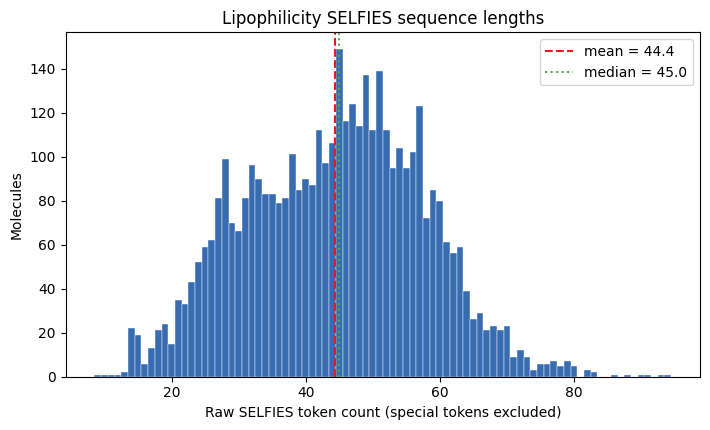

,statistic,value
0,run_mode,assignment-compliant
1,original_molecule_count,4200
2,invalid_or_removed_count,6
3,invalid_smiles_count,0
4,sanitization_failure_count,0
5,canonicalization_failure_count,0
6,duplicate_count,0
7,selfies_conversion_failure_count,0
8,selfies_too_long_count,6
9,usable_molecule_count,4194


Special token IDs: {'<pad>': 0, '<bos>': 1, '<eos>': 2, '<unk>': 3}
Unknown-token audit: {'val': {'unknown_tokens': 3, 'total_tokens': 18663, 'unknown_percentage': 0.016074586079408454}, 'test': {'unknown_tokens': 0, 'total_tokens': 18556, 'unknown_percentage': 0.0}}


In [7]:
rng = np.random.default_rng(CFG.seed)
permutation = rng.permutation(len(usable_records))
n_train = int(CFG.train_ratio * len(usable_records))
n_val = int(CFG.val_ratio * len(usable_records))
split_by_index: Dict[int, str] = {}
for idx in permutation[:n_train]:
    split_by_index[int(idx)] = "train"
for idx in permutation[n_train:n_train + n_val]:
    split_by_index[int(idx)] = "val"
for idx in permutation[n_train + n_val:]:
    split_by_index[int(idx)] = "test"
for index, record in enumerate(usable_records):
    record["split"] = split_by_index[index]

split_df = pd.DataFrame([{
    "original_index": r["original_index"],
    "canonical_smiles": r["canonical_smiles"],
    "split": r["split"],
    "target": r["target"],
    "selfies_token_count": len(r["tokens"]),
    "atom_count": r["atom_count"],
    "undirected_bond_count": r["undirected_bond_count"],
} for r in usable_records])
split_df.to_csv(RESULT_DIR / "dataset_splits.csv", index=False)

split_sets = {
    name: set(split_df.loc[split_df.split == name, "canonical_smiles"])
    for name in ("train", "val", "test")
}
assert split_sets["train"].isdisjoint(split_sets["val"])
assert split_sets["train"].isdisjoint(split_sets["test"])
assert split_sets["val"].isdisjoint(split_sets["test"])
assert sum(len(v) for v in split_sets.values()) == len(usable_records)

SPECIAL_TOKENS = ("<pad>", "<bos>", "<eos>", "<unk>")
token_frequencies = Counter(
    token
    for r in usable_records if r["split"] == "train"
    for token in r["tokens"]
)
vocabulary_tokens = list(SPECIAL_TOKENS) + sorted(token_frequencies)
token_to_id = {token: i for i, token in enumerate(vocabulary_tokens)}
id_to_token = {i: token for token, i in token_to_id.items()}
pad_id, bos_id, eos_id, unk_id = [token_to_id[t] for t in SPECIAL_TOKENS]
assert tuple(vocabulary_tokens[:4]) == SPECIAL_TOKENS

def encode_selfies_tokens(tokens: Sequence[str]) -> List[int]:
    return [bos_id] + [token_to_id.get(t, unk_id) for t in tokens] + [eos_id]

for record in usable_records:
    record["token_ids"] = encode_selfies_tokens(record["tokens"])

unknown_summary: Dict[str, Dict[str, float]] = {}
for split in ("val", "test"):
    tokens = [t for r in usable_records if r["split"] == split for t in r["tokens"]]
    unknown = sum(t not in token_to_id for t in tokens)
    unknown_summary[split] = {
        "unknown_tokens": int(unknown),
        "total_tokens": int(len(tokens)),
        "unknown_percentage": 100.0 * unknown / max(1, len(tokens)),
    }

vocabulary_payload = {
    "special_tokens": list(SPECIAL_TOKENS),
    "special_token_ids": {t: token_to_id[t] for t in SPECIAL_TOKENS},
    "token_to_id": token_to_id,
    "id_to_token": {str(k): v for k, v in id_to_token.items()},
    "training_token_frequencies": dict(sorted(token_frequencies.items())),
    "built_from_split": "train",
    "unknown_summary": unknown_summary,
}
with open(RESULT_DIR / "selfies_vocabulary.json", "w", encoding="utf-8") as handle:
    json.dump(vocabulary_payload, handle, indent=2, ensure_ascii=False)

lengths = np.array([len(r["tokens"]) for r in usable_records])
dataset_stats = {
    "run_mode": RUN_MODE,
    "original_molecule_count": len(raw_dataset),
    "invalid_or_removed_count": int((audit_df.cleaning_status == "removed").sum()),
    "invalid_smiles_count": int((audit_df.removal_reason == "invalid_smiles").sum()),
    "sanitization_failure_count": int((audit_df.removal_reason == "sanitization_failure").sum()),
    "canonicalization_failure_count": int((audit_df.removal_reason == "canonicalization_failure").sum()),
    "duplicate_count": int((audit_df.removal_reason == "duplicate_canonical").sum()),
    "selfies_conversion_failure_count": int((audit_df.removal_reason == "selfies_conversion_failure").sum()),
    "selfies_too_long_count": int((audit_df.removal_reason == "selfies_too_long").sum()),
    "usable_molecule_count": len(usable_records),
    "train_size": int((split_df.split == "train").sum()),
    "validation_size": int((split_df.split == "val").sum()),
    "test_size": int((split_df.split == "test").sum()),
    "vocabulary_size": len(vocabulary_tokens),
    "average_atom_count": float(np.mean([r["atom_count"] for r in usable_records])),
    "average_undirected_bond_count": float(np.mean([r["undirected_bond_count"] for r in usable_records])),
    "selfies_length_min": int(lengths.min()),
    "selfies_length_mean": float(lengths.mean()),
    "selfies_length_median": float(np.median(lengths)),
    "selfies_length_max": int(lengths.max()),
    "validation_unknown_tokens": unknown_summary["val"]["unknown_tokens"],
    "validation_unknown_percentage": unknown_summary["val"]["unknown_percentage"],
    "test_unknown_tokens": unknown_summary["test"]["unknown_tokens"],
    "test_unknown_percentage": unknown_summary["test"]["unknown_percentage"],
}
stats_df = pd.DataFrame(
    [{"statistic": key, "value": value} for key, value in dataset_stats.items()]
)
stats_df.to_csv(RESULT_DIR / "dataset_statistics.csv", index=False)

plt.figure(figsize=(7.2, 4.4))
bins = np.arange(lengths.min(), lengths.max() + 2) - 0.5
plt.hist(lengths, bins=bins, color="#386cb0", edgecolor="white", linewidth=0.3)
plt.axvline(lengths.mean(), color="#e41a1c", linestyle="--",
            label=f"mean = {lengths.mean():.1f}")
plt.axvline(np.median(lengths), color="#4daf4a", linestyle=":",
            label=f"median = {np.median(lengths):.1f}")
plt.xlabel("Raw SELFIES token count (special tokens excluded)")
plt.ylabel("Molecules")
plt.title("Lipophilicity SELFIES sequence lengths")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "selfies_length_distribution.png", dpi=180)
plt.show()

display(stats_df)
print("Special token IDs:", {t: token_to_id[t] for t in SPECIAL_TOKENS})
print("Unknown-token audit:", unknown_summary)

In [8]:
class MolecularPairDataset(Dataset):
    '''Paired graph--SELFIES samples with cached canonical graphs.'''

    def __init__(self, records: Sequence[Dict[str, Any]], split: str):
        self.records = [r for r in records if r["split"] == split]
        self.split = split

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, index: int) -> Dict[str, Any]:
        r = self.records[index]
        return {
            "graph": r["graph"],
            "token_ids": torch.tensor(r["token_ids"], dtype=torch.long),
            "canonical_smiles": r["canonical_smiles"],
            "selfies": r["selfies"],
            "target": float(r["target"]),
            "split": r["split"],
            "original_index": int(r["original_index"]),
            "sample_order": int(r["graph"].sample_order.item()),
        }

def paired_collate_fn(samples: Sequence[Dict[str, Any]]) -> Dict[str, Any]:
    token_ids = pad_sequence(
        [s["token_ids"] for s in samples],
        batch_first=True,
        padding_value=pad_id,
    )
    batch = {
        "graph": Batch.from_data_list([s["graph"] for s in samples]),
        "token_ids": token_ids,
        "attention_mask": token_ids.ne(pad_id),
        "lengths": torch.tensor([len(s["token_ids"]) for s in samples], dtype=torch.long),
        "canonical_smiles": [s["canonical_smiles"] for s in samples],
        "selfies": [s["selfies"] for s in samples],
        "target": torch.tensor([s["target"] for s in samples], dtype=torch.float32),
        "split": [s["split"] for s in samples],
        "original_index": torch.tensor([s["original_index"] for s in samples]),
        "sample_order": torch.tensor([s["sample_order"] for s in samples]),
    }
    if not torch.equal(batch["graph"].sample_order.cpu(), batch["sample_order"]):
        raise AssertionError("Graph and sequence sample orders became misaligned.")
    if batch["graph"].edge_weight.numel() != batch["graph"].edge_index.shape[1]:
        raise AssertionError("Batched edge weights are not edge-aligned.")
    return batch

datasets = {
    split: MolecularPairDataset(usable_records, split)
    for split in ("train", "val", "test")
}

def make_loaders(batch_size: int) -> Dict[str, DataLoader]:
    generator = torch.Generator().manual_seed(CFG.seed)
    return {
        split: DataLoader(
            datasets[split],
            batch_size=batch_size,
            shuffle=(split == "train"),
            num_workers=EFFECTIVE_NUM_WORKERS,
            collate_fn=paired_collate_fn,
            pin_memory=AMP_ENABLED,
            persistent_workers=EFFECTIVE_NUM_WORKERS > 0,
            generator=generator if split == "train" else None,
        )
        for split in ("train", "val", "test")
    }

EFFECTIVE_BATCH_SIZE = CFG.batch_size
loaders = make_loaders(EFFECTIVE_BATCH_SIZE)
sanity_batch = next(iter(loaders["train"]))
assert sanity_batch["token_ids"].shape[0] == sanity_batch["graph"].num_graphs
assert all(
    s == usable_records[int(i)]["canonical_smiles"]
    for s, i in zip(sanity_batch["canonical_smiles"], sanity_batch["sample_order"])
)
print("Paired batch graphs/tokens:", sanity_batch["graph"], sanity_batch["token_ids"].shape)
print("Split sizes:", {k: len(v) for k, v in datasets.items()})

dataset_preparation_seconds = time.perf_counter() - data_prep_start
print(f"Dataset preparation time: {dataset_preparation_seconds:.3f} s")

Paired batch graphs/tokens: DataBatch(x=[6933, 9], edge_index=[2, 15090], edge_attr=[15090, 3], smiles=[256], edge_weight=[15090], y=[256], sample_order=[256], batch=[6933], ptr=[257]) torch.Size([256, 80])
Split sizes: {'train': 3355, 'val': 419, 'test': 420}
Dataset preparation time: 8.100 s


## 10--19. GCN, causal Transformer, projection heads, and objectives

Every categorical atom field has a separate embedding table; their vectors are
added elementwise. Exactly three residual `GCNConv` blocks receive the scalar
bond-order weights. Global mean pooling converts variable-size node sets into one
graph vector. The sequence encoder has exactly four layers, six heads, learned
token/position embeddings, a causal mask, and an EOS-state molecular vector.
Separate two-layer heads produce unit-normalized graph and sequence projections.

In [9]:
class AtomFeatureEmbedding(nn.Module):
    def __init__(self, cardinalities: Sequence[int], hidden_dim: int):
        super().__init__()
        self.cardinalities = list(cardinalities)
        self.embeddings = nn.ModuleList([
            nn.Embedding(cardinality, hidden_dim)
            for cardinality in self.cardinalities
        ])
        self.reset_parameters()

    def reset_parameters(self) -> None:
        for embedding in self.embeddings:
            nn.init.xavier_uniform_(embedding.weight)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.shape[1] != len(self.embeddings):
            raise ValueError(
                f"Expected {len(self.embeddings)} atom fields, got {x.shape[1]}."
            )
        result = 0
        for column, (embedding, cardinality) in enumerate(
            zip(self.embeddings, self.cardinalities)
        ):
            values = x[:, column].long()
            unknown_id = cardinality - 1
            values = torch.where(
                (values >= 0) & (values < unknown_id),
                values,
                torch.full_like(values, unknown_id),
            )
            result = result + embedding(values)
        return result

class GCNResidualBlock(nn.Module):
    def __init__(self, hidden_dim: int, dropout: float):
        super().__init__()
        self.conv = GCNConv(
            hidden_dim, hidden_dim, add_self_loops=True, normalize=True
        )
        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        x: torch.Tensor,
        edge_index: torch.Tensor,
        edge_weight: torch.Tensor,
    ) -> torch.Tensor:
        residual = x
        x = self.conv(x, edge_index, edge_weight=edge_weight)
        x = self.norm(x)
        x = F.gelu(x)
        x = self.dropout(x)
        return residual + x

class MolecularGCN(nn.Module):
    def __init__(
        self,
        cardinalities: Sequence[int],
        hidden_dim: int,
        num_layers: int,
        dropout: float,
    ):
        super().__init__()
        if num_layers != 3:
            raise ValueError("The assignment requires exactly three GCN layers.")
        self.atom_embedding = AtomFeatureEmbedding(cardinalities, hidden_dim)
        self.blocks = nn.ModuleList([
            GCNResidualBlock(hidden_dim, dropout) for _ in range(num_layers)
        ])
        self.final_norm = nn.LayerNorm(hidden_dim)

    def forward(self, graph_batch: Batch) -> torch.Tensor:
        x = self.atom_embedding(graph_batch.x)
        for block in self.blocks:
            x = block(x, graph_batch.edge_index, graph_batch.edge_weight)
        x = self.final_norm(x)
        # Graphs contain different numbers of atoms. Global pooling yields one
        # fixed-size molecular vector per graph for retrieval and contrastive loss.
        return global_mean_pool(x, graph_batch.batch)

class CausalSelfiesTransformer(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        d_model: int,
        nhead: int,
        num_layers: int,
        ff_dim: int,
        dropout: float,
        max_positions: int,
        pad_token_id: int,
    ):
        super().__init__()
        if (d_model, nhead, num_layers, ff_dim) != (192, 6, 4, 512):
            raise ValueError(
                "Assignment architecture must be d_model=192, heads=6, "
                "layers=4, feedforward=512."
            )
        self.pad_token_id = pad_token_id
        self.max_positions = max_positions
        self.token_embedding = nn.Embedding(
            vocab_size, d_model, padding_idx=pad_token_id
        )
        self.position_embedding = nn.Embedding(max_positions, d_model)
        self.input_dropout = nn.Dropout(dropout)
        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ff_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(
            layer, num_layers=num_layers, enable_nested_tensor=False
        )
        self.final_norm = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.token_embedding.weight
        nn.init.normal_(self.token_embedding.weight, mean=0.0, std=0.02)
        nn.init.normal_(self.position_embedding.weight, mean=0.0, std=0.02)
        with torch.no_grad():
            self.token_embedding.weight[pad_token_id].zero_()

    @staticmethod
    def causal_mask(length: int, device: torch.device) -> torch.Tensor:
        return torch.triu(
            torch.ones(length, length, dtype=torch.bool, device=device),
            diagonal=1,
        )

    def forward(self, token_ids: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        batch_size, seq_len = token_ids.shape
        if seq_len > self.max_positions:
            raise ValueError(
                f"Sequence length {seq_len} exceeds {self.max_positions} positions."
            )
        positions = torch.arange(seq_len, device=token_ids.device).unsqueeze(0)
        positions = positions.expand(batch_size, -1)
        hidden = self.token_embedding(token_ids) + self.position_embedding(positions)
        hidden = self.input_dropout(hidden)
        hidden = self.encoder(
            hidden,
            mask=self.causal_mask(seq_len, token_ids.device),
            src_key_padding_mask=token_ids.eq(self.pad_token_id),
            is_causal=True,
        )
        hidden = self.final_norm(hidden)
        return hidden, self.lm_head(hidden)

    def eos_representation(
        self,
        hidden: torch.Tensor,
        token_ids: torch.Tensor,
        eos_token_id: int,
    ) -> torch.Tensor:
        eos_mask = token_ids.eq(eos_token_id)
        has_eos = eos_mask.any(dim=1)
        first_eos = eos_mask.float().argmax(dim=1)
        last_nonpad = token_ids.ne(self.pad_token_id).sum(dim=1).sub(1).clamp_min(0)
        positions = torch.where(has_eos, first_eos, last_nonpad)
        return hidden[
            torch.arange(hidden.shape[0], device=hidden.device), positions
        ]

class ProjectionHead(nn.Module):
    def __init__(self, input_dim: int, projection_dim: int, dropout: float):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.GELU(),
            nn.LayerNorm(input_dim),
            nn.Dropout(dropout),
            nn.Linear(input_dim, projection_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.normalize(self.network(x), dim=-1)

class JointGraphSequenceModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.gcn = MolecularGCN(
            ATOM_FEATURE_CARDINALITIES,
            CFG.gcn_hidden_dim,
            CFG.gcn_num_layers,
            CFG.gcn_dropout,
        )
        self.transformer = CausalSelfiesTransformer(
            vocab_size=len(vocabulary_tokens),
            d_model=CFG.transformer_d_model,
            nhead=CFG.transformer_nhead,
            num_layers=CFG.transformer_num_layers,
            ff_dim=CFG.transformer_ff_dim,
            dropout=CFG.transformer_dropout,
            max_positions=CFG.max_selfies_tokens + 2,
            pad_token_id=pad_id,
        )
        self.graph_projection = ProjectionHead(
            CFG.gcn_hidden_dim, CFG.projection_dim, CFG.gcn_dropout
        )
        self.sequence_projection = ProjectionHead(
            CFG.transformer_d_model,
            CFG.projection_dim,
            CFG.transformer_dropout,
        )

    def encode_graph(self, graph_batch: Batch) -> torch.Tensor:
        return self.graph_projection(self.gcn(graph_batch))

    def encode_sequence(
        self, token_ids: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        hidden, logits = self.transformer(token_ids)
        eos_hidden = self.transformer.eos_representation(hidden, token_ids, eos_id)
        return self.sequence_projection(eos_hidden), hidden, logits

    def forward(self, graph_batch: Batch, token_ids: torch.Tensor) -> Dict[str, torch.Tensor]:
        graph_projection = self.encode_graph(graph_batch)
        sequence_projection, hidden, logits = self.encode_sequence(token_ids)
        return {
            "graph_projection": graph_projection,
            "sequence_projection": sequence_projection,
            "hidden": hidden,
            "logits": logits,
        }

def token_loss_and_counts(
    logits: torch.Tensor, token_ids: torch.Tensor
) -> Tuple[torch.Tensor, int, int]:
    shifted_logits = logits[:, :-1].contiguous()
    shifted_targets = token_ids[:, 1:].contiguous()
    loss = F.cross_entropy(
        shifted_logits.view(-1, shifted_logits.shape[-1]),
        shifted_targets.view(-1),
        ignore_index=pad_id,
    )
    with torch.no_grad():
        valid = shifted_targets.ne(pad_id)
        correct = (
            shifted_logits.argmax(dim=-1).eq(shifted_targets) & valid
        ).sum().item()
        count = valid.sum().item()
    return loss, int(correct), int(count)

def symmetric_contrastive_loss(
    graph_projection: torch.Tensor,
    sequence_projection: torch.Tensor,
    temperature: float,
) -> Tuple[torch.Tensor, torch.Tensor]:
    logits = graph_projection @ sequence_projection.T / temperature
    labels = torch.arange(logits.shape[0], device=logits.device)
    loss = 0.5 * (
        F.cross_entropy(logits, labels)
        + F.cross_entropy(logits.T, labels)
    )
    return loss, logits

def positive_pair_cosine_loss(
    graph_projection: torch.Tensor, sequence_projection: torch.Tensor
) -> torch.Tensor:
    return (1.0 - (graph_projection * sequence_projection).sum(dim=-1)).mean()

def safe_perplexity(token_loss: float) -> float:
    return float(math.exp(min(float(token_loss), 20.0)))

model = JointGraphSequenceModel().to(DEVICE)
print(model)
print("Trainable parameters:", f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

JointGraphSequenceModel(
  (gcn): MolecularGCN(
    (atom_embedding): AtomFeatureEmbedding(
      (embeddings): ModuleList(
        (0): Embedding(120, 192)
        (1): Embedding(10, 192)
        (2): Embedding(12, 192)
        (3): Embedding(13, 192)
        (4): Embedding(10, 192)
        (5): Embedding(6, 192)
        (6): Embedding(9, 192)
        (7-8): 2 x Embedding(3, 192)
      )
    )
    (blocks): ModuleList(
      (0-2): 3 x GCNResidualBlock(
        (conv): GCNConv(192, 192)
        (norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (final_norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  )
  (transformer): CausalSelfiesTransformer(
    (token_embedding): Embedding(52, 192, padding_idx=0)
    (position_embedding): Embedding(102, 192)
    (input_dropout): Dropout(p=0.1, inplace=False)
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-3): 4 x TransformerEncoderL

In [10]:
# Architectural and masking sanity checks.
model.eval()
tiny_tokens = torch.tensor([
    [bos_id, next(iter(token_frequencies)) and token_to_id[next(iter(token_frequencies))], eos_id, pad_id],
    [bos_id, eos_id, pad_id, pad_id],
], device=DEVICE)
causal = model.transformer.causal_mask(tiny_tokens.shape[1], DEVICE)
assert torch.equal(causal, torch.triu(causal, diagonal=1))
assert causal[0, 1] and not causal[1, 0]  # future hidden; past visible
with torch.inference_mode():
    hidden, tiny_logits = model.transformer(tiny_tokens)
    reps = model.transformer.eos_representation(hidden, tiny_tokens, eos_id)
assert reps.shape == (2, CFG.transformer_d_model)

# A pad target must not alter CE when its corresponding logits change.
dummy_logits = torch.randn(1, 3, len(vocabulary_tokens), device=DEVICE)
dummy_ids = torch.tensor([[bos_id, eos_id, pad_id]], device=DEVICE)
loss_a, _, count_a = token_loss_and_counts(dummy_logits, dummy_ids)
dummy_logits[:, -2, :] = 1000.0
loss_b, _, count_b = token_loss_and_counts(dummy_logits, dummy_ids)
assert torch.allclose(loss_a, loss_b) and count_a == count_b == 1

check_batch = {
    key: value.to(DEVICE) if key == "graph" else value
    for key, value in sanity_batch.items()
}
check_tokens = sanity_batch["token_ids"].to(DEVICE)
with torch.inference_mode():
    check_out = model(check_batch["graph"], check_tokens)
    _, similarity_logits = symmetric_contrastive_loss(
        check_out["graph_projection"],
        check_out["sequence_projection"],
        CFG.contrastive_temperature,
    )
assert check_out["graph_projection"].shape == check_out["sequence_projection"].shape
assert check_out["graph_projection"].shape[1] == CFG.projection_dim
assert torch.allclose(
    check_out["graph_projection"].norm(dim=-1),
    torch.ones(check_out["graph_projection"].shape[0], device=DEVICE),
    atol=1e-4,
)
assert torch.allclose(
    check_out["sequence_projection"].norm(dim=-1),
    torch.ones(check_out["sequence_projection"].shape[0], device=DEVICE),
    atol=1e-4,
)
positive_pair_positions = torch.arange(similarity_logits.shape[0], device=DEVICE)
assert torch.equal(positive_pair_positions, torch.arange(similarity_logits.shape[0], device=DEVICE))
print("Architecture, unit-norm, pair-diagonal, causal-mask, and pad-loss checks passed.")

Architecture, unit-norm, pair-diagonal, causal-mask, and pad-loss checks passed.


## 14--16. Stage 1 warm-up and Stage 2 joint training

Warm-up optimizes only next-token cross-entropy. Joint training then optimizes
token loss plus symmetric in-batch contrastive loss and positive-pair cosine loss.
Both stages use AdamW, cosine decay, gradient clipping, and CUDA mixed precision
when available. The full run uses exactly 15 warm-up epochs and up to 40 joint
epochs with validation early stopping.

In [11]:
def make_grad_scaler() -> torch.amp.GradScaler:
    try:
        return torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    except TypeError:
        return torch.amp.GradScaler(enabled=AMP_ENABLED)

def move_batch(batch: Dict[str, Any]) -> Tuple[Batch, torch.Tensor]:
    return (
        batch["graph"].to(DEVICE, non_blocking=True),
        batch["token_ids"].to(DEVICE, non_blocking=True),
    )

def run_lm_epoch(
    transformer: CausalSelfiesTransformer,
    loader: DataLoader,
    optimizer: Optional[torch.optim.Optimizer] = None,
    scaler: Optional[torch.amp.GradScaler] = None,
) -> Dict[str, float]:
    training = optimizer is not None
    transformer.train(training)
    loss_sum = 0.0
    correct_sum = 0
    token_count = 0
    progress = tqdm(loader, leave=False, desc="LM train" if training else "LM val")
    for batch in progress:
        token_ids = batch["token_ids"].to(DEVICE, non_blocking=True)
        if training:
            optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=AMP_ENABLED):
            _, logits = transformer(token_ids)
            loss, correct, count = token_loss_and_counts(logits, token_ids)
        if training:
            assert scaler is not None
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                transformer.parameters(), CFG.max_grad_norm
            )
            scaler.step(optimizer)
            scaler.update()
        loss_sum += float(loss.detach()) * count
        correct_sum += correct
        token_count += count
    average_loss = loss_sum / max(1, token_count)
    return {
        "token_loss": average_loss,
        "token_accuracy": correct_sum / max(1, token_count),
        "perplexity": safe_perplexity(average_loss),
        "token_count": token_count,
    }

@torch.inference_mode()
def evaluate_lm(
    transformer: CausalSelfiesTransformer, loader: DataLoader
) -> Dict[str, float]:
    return run_lm_epoch(transformer, loader)

def checkpoint_payload(
    epoch: int,
    validation_metrics: Dict[str, float],
    optimizer: Optional[torch.optim.Optimizer] = None,
    scheduler: Optional[Any] = None,
) -> Dict[str, Any]:
    payload = {
        "epoch": int(epoch),
        "model_state": model.state_dict(),
        "transformer_state": model.transformer.state_dict(),
        "configuration": asdict(CFG),
        "run_mode": RUN_MODE,
        "vocabulary": vocabulary_payload,
        "validation_metrics": validation_metrics,
        "feature_names": ATOM_FEATURE_NAMES,
        "feature_cardinalities": ATOM_FEATURE_CARDINALITIES,
        "special_token_ids": {
            "pad": pad_id, "bos": bos_id, "eos": eos_id, "unk": unk_id
        },
    }
    if optimizer is not None:
        payload["optimizer_state"] = optimizer.state_dict()
    if scheduler is not None:
        payload["scheduler_state"] = scheduler.state_dict()
    return payload

In [12]:
warmup_start = time.perf_counter()
lm_optimizer = torch.optim.AdamW(
    model.transformer.parameters(),
    lr=CFG.lm_learning_rate,
    weight_decay=CFG.weight_decay,
)
lm_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    lm_optimizer, T_max=max(1, WARMUP_EPOCHS)
)
lm_scaler = make_grad_scaler()
lm_history_rows: List[Dict[str, float]] = []
best_warmup_loss = float("inf")
best_warmup_epoch = 0

for epoch in range(1, WARMUP_EPOCHS + 1):
    train_metrics = run_lm_epoch(
        model.transformer, loaders["train"], lm_optimizer, lm_scaler
    )
    val_metrics = evaluate_lm(model.transformer, loaders["val"])
    row = {
        "epoch": epoch,
        "train_token_loss": train_metrics["token_loss"],
        "val_token_loss": val_metrics["token_loss"],
        "train_token_accuracy": train_metrics["token_accuracy"],
        "val_token_accuracy": val_metrics["token_accuracy"],
        "train_perplexity": train_metrics["perplexity"],
        "val_perplexity": val_metrics["perplexity"],
        "learning_rate": lm_optimizer.param_groups[0]["lr"],
    }
    lm_history_rows.append(row)
    if val_metrics["token_loss"] < best_warmup_loss:
        best_warmup_loss = val_metrics["token_loss"]
        best_warmup_epoch = epoch
        torch.save(
            checkpoint_payload(
                epoch, val_metrics, lm_optimizer, lm_scheduler
            ),
            CHECKPOINT_DIR / "best_lm_warmup.pt",
        )
    lm_scheduler.step()
    print(
        f"Warm-up {epoch:02d}/{WARMUP_EPOCHS}: "
        f"train CE={train_metrics['token_loss']:.4f}, "
        f"val CE={val_metrics['token_loss']:.4f}, "
        f"val acc={val_metrics['token_accuracy']:.3f}, "
        f"val ppl={val_metrics['perplexity']:.2f}"
    )

lm_warmup_seconds = time.perf_counter() - warmup_start
lm_history_df = pd.DataFrame(lm_history_rows)
lm_history_df.to_csv(RESULT_DIR / "lm_warmup_history.csv", index=False)
warmup_checkpoint = torch.load(
    CHECKPOINT_DIR / "best_lm_warmup.pt", map_location=DEVICE, weights_only=False
)
model.transformer.load_state_dict(warmup_checkpoint["transformer_state"])
print(
    f"Best warm-up epoch: {best_warmup_epoch}; "
    f"runtime: {lm_warmup_seconds:.2f} s"
)

LM train:   0%|          | 0/14 [00:00<?, ?it/s]

LM val:   0%|          | 0/2 [00:00<?, ?it/s]

Warm-up 01/15: train CE=2.9698, val CE=2.5479, val acc=0.352, val ppl=12.78


LM train:   0%|          | 0/14 [00:00<?, ?it/s]

LM val:   0%|          | 0/2 [00:00<?, ?it/s]

...

LM val:   0%|          | 0/2 [00:00<?, ?it/s]

Warm-up 14/15: train CE=1.6719, val CE=1.6376, val acc=0.506, val ppl=5.14


LM train:   0%|          | 0/14 [00:00<?, ?it/s]

LM val:   0%|          | 0/2 [00:00<?, ?it/s]

Warm-up 15/15: train CE=1.6701, val CE=1.6361, val acc=0.506, val ppl=5.14
Best warm-up epoch: 15; runtime: 522.88 s


In [13]:
def run_joint_epoch(
    joint_model: JointGraphSequenceModel,
    loader: DataLoader,
    optimizer: Optional[torch.optim.Optimizer] = None,
    scaler: Optional[torch.amp.GradScaler] = None,
) -> Dict[str, float]:
    training = optimizer is not None
    joint_model.train(training)
    sums = Counter()
    token_loss_sum = 0.0
    token_correct = 0
    token_count = 0
    sample_count = 0
    progress = tqdm(loader, leave=False, desc="Joint train" if training else "Joint val")
    for batch in progress:
        graph_batch, token_ids = move_batch(batch)
        if training:
            optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=AMP_ENABLED):
            output = joint_model(graph_batch, token_ids)
            token_loss, correct, count = token_loss_and_counts(
                output["logits"], token_ids
            )
            contrastive_loss, _ = symmetric_contrastive_loss(
                output["graph_projection"],
                output["sequence_projection"],
                CFG.contrastive_temperature,
            )
            pair_loss = positive_pair_cosine_loss(
                output["graph_projection"], output["sequence_projection"]
            )
            total_loss = (
                token_loss
                + CFG.lambda_contrastive * contrastive_loss
                + CFG.gamma_pair * pair_loss
            )
        if training:
            assert scaler is not None
            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                joint_model.parameters(), CFG.max_grad_norm
            )
            scaler.step(optimizer)
            scaler.update()

        batch_size = token_ids.shape[0]
        sums["total_loss"] += float(total_loss.detach()) * batch_size
        sums["contrastive_loss"] += float(contrastive_loss.detach()) * batch_size
        sums["pair_loss"] += float(pair_loss.detach()) * batch_size
        token_loss_sum += float(token_loss.detach()) * count
        token_correct += correct
        token_count += count
        sample_count += batch_size

    token_loss_average = token_loss_sum / max(1, token_count)
    return {
        "total_loss": sums["total_loss"] / max(1, sample_count),
        "token_loss": token_loss_average,
        "contrastive_loss": sums["contrastive_loss"] / max(1, sample_count),
        "pair_loss": sums["pair_loss"] / max(1, sample_count),
        "token_accuracy": token_correct / max(1, token_count),
        "perplexity": safe_perplexity(token_loss_average),
        "sample_count": sample_count,
        "token_count": token_count,
    }

@torch.inference_mode()
def evaluate_joint(
    joint_model: JointGraphSequenceModel, loader: DataLoader
) -> Dict[str, float]:
    return run_joint_epoch(joint_model, loader)

In [14]:
joint_start = time.perf_counter()
joint_optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG.joint_learning_rate,
    weight_decay=CFG.weight_decay,
)
joint_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    joint_optimizer, T_max=max(1, JOINT_EPOCHS)
)
joint_scaler = make_grad_scaler()
joint_history_rows: List[Dict[str, float]] = []
best_joint_loss = float("inf")
best_joint_epoch = 0
epochs_without_improvement = 0

for epoch in range(1, JOINT_EPOCHS + 1):
    train_metrics = run_joint_epoch(
        model, loaders["train"], joint_optimizer, joint_scaler
    )
    val_metrics = evaluate_joint(model, loaders["val"])
    row: Dict[str, float] = {"epoch": epoch}
    for prefix, metrics in (("train", train_metrics), ("val", val_metrics)):
        for key in (
            "total_loss", "token_loss", "contrastive_loss", "pair_loss",
            "token_accuracy", "perplexity"
        ):
            row[f"{prefix}_{key}"] = metrics[key]
    row["learning_rate"] = joint_optimizer.param_groups[0]["lr"]
    joint_history_rows.append(row)

    if val_metrics["total_loss"] < best_joint_loss - 1e-8:
        best_joint_loss = val_metrics["total_loss"]
        best_joint_epoch = epoch
        epochs_without_improvement = 0
        torch.save(
            checkpoint_payload(
                epoch, val_metrics, joint_optimizer, joint_scheduler
            ),
            CHECKPOINT_DIR / "best_joint_model.pt",
        )
    else:
        epochs_without_improvement += 1
    joint_scheduler.step()
    print(
        f"Joint {epoch:02d}/{JOINT_EPOCHS}: "
        f"train total={train_metrics['total_loss']:.4f}, "
        f"val total={val_metrics['total_loss']:.4f}, "
        f"val CE={val_metrics['token_loss']:.4f}, "
        f"val acc={val_metrics['token_accuracy']:.3f}"
    )
    if epochs_without_improvement >= CFG.early_stopping_patience:
        print(f"Early stopping after {epoch} epochs.")
        break

joint_training_seconds = time.perf_counter() - joint_start
joint_history_df = pd.DataFrame(joint_history_rows)
joint_history_df.to_csv(RESULT_DIR / "joint_training_history.csv", index=False)

best_checkpoint = torch.load(
    CHECKPOINT_DIR / "best_joint_model.pt", map_location=DEVICE, weights_only=False
)
model.load_state_dict(best_checkpoint["model_state"])
model.eval()
best_val_metrics = best_checkpoint["validation_metrics"]
print(
    f"Best joint epoch: {best_joint_epoch}; "
    f"best validation total loss: {best_joint_loss:.4f}; "
    f"runtime: {joint_training_seconds:.2f} s"
)

Joint train:   0%|          | 0/14 [00:00<?, ?it/s]

Joint val:   0%|          | 0/2 [00:00<?, ?it/s]

Joint 01/40: train total=7.1652, val total=6.2798, val CE=1.6761, val acc=0.498


Joint train:   0%|          | 0/14 [00:00<?, ?it/s]

Joint val:   0%|          | 0/2 [00:00<?, ?it/s]

...

Joint val:   0%|          | 0/2 [00:00<?, ?it/s]

Joint 39/40: train total=2.8423, val total=2.5081, val CE=1.6158, val acc=0.515


Joint train:   0%|          | 0/14 [00:00<?, ?it/s]

Joint val:   0%|          | 0/2 [00:00<?, ?it/s]

Joint 40/40: train total=2.8338, val total=2.5082, val CE=1.6157, val acc=0.515
Best joint epoch: 38; best validation total loss: 2.5053; runtime: 1565.51 s


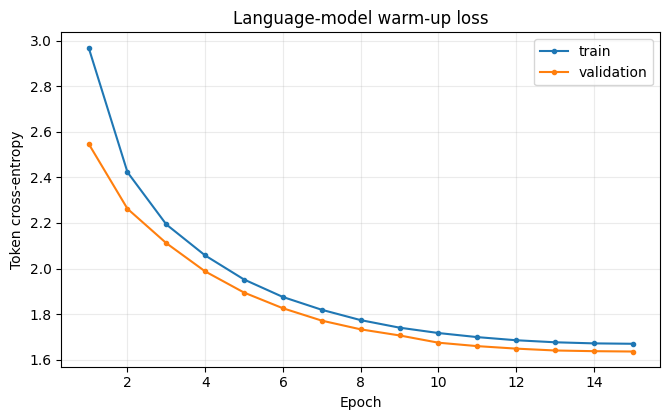

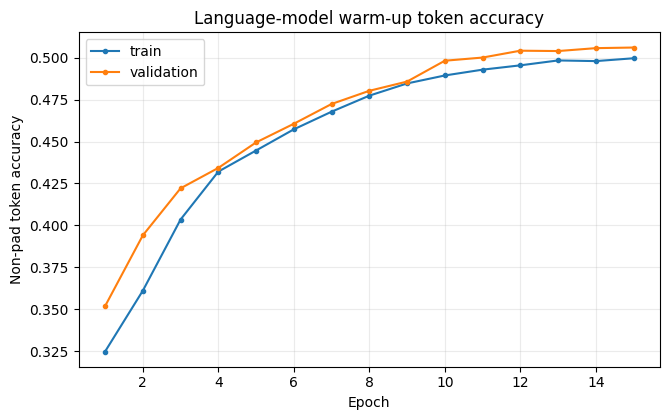

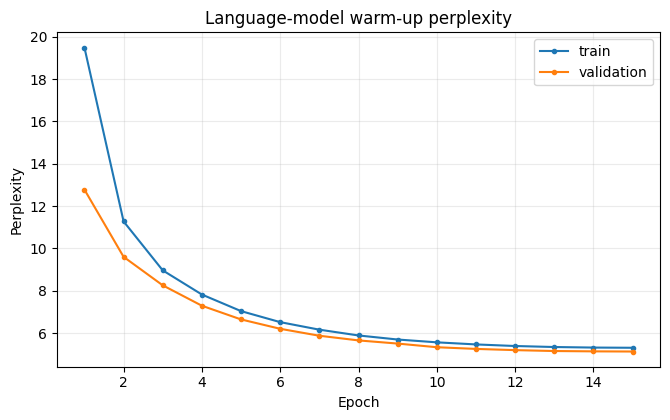

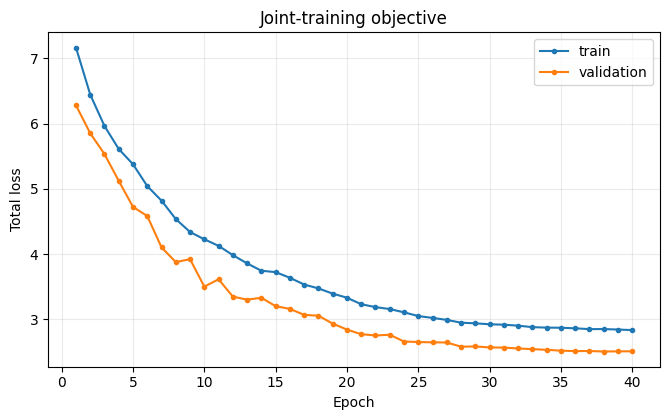

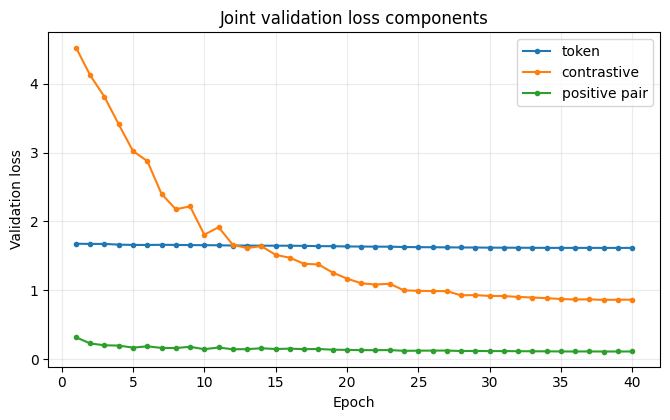

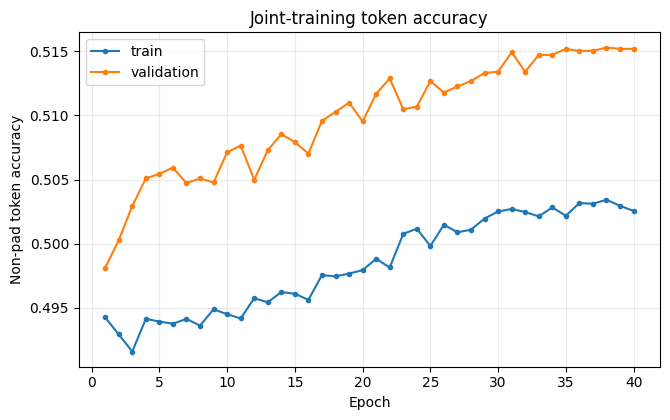

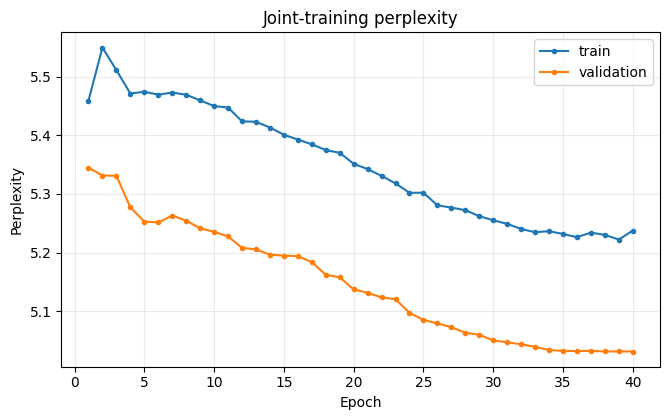

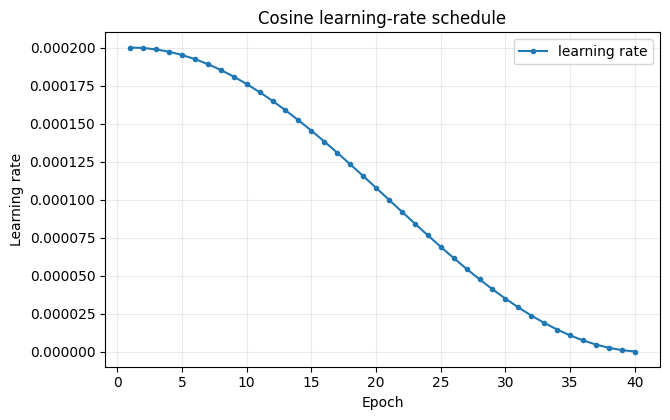

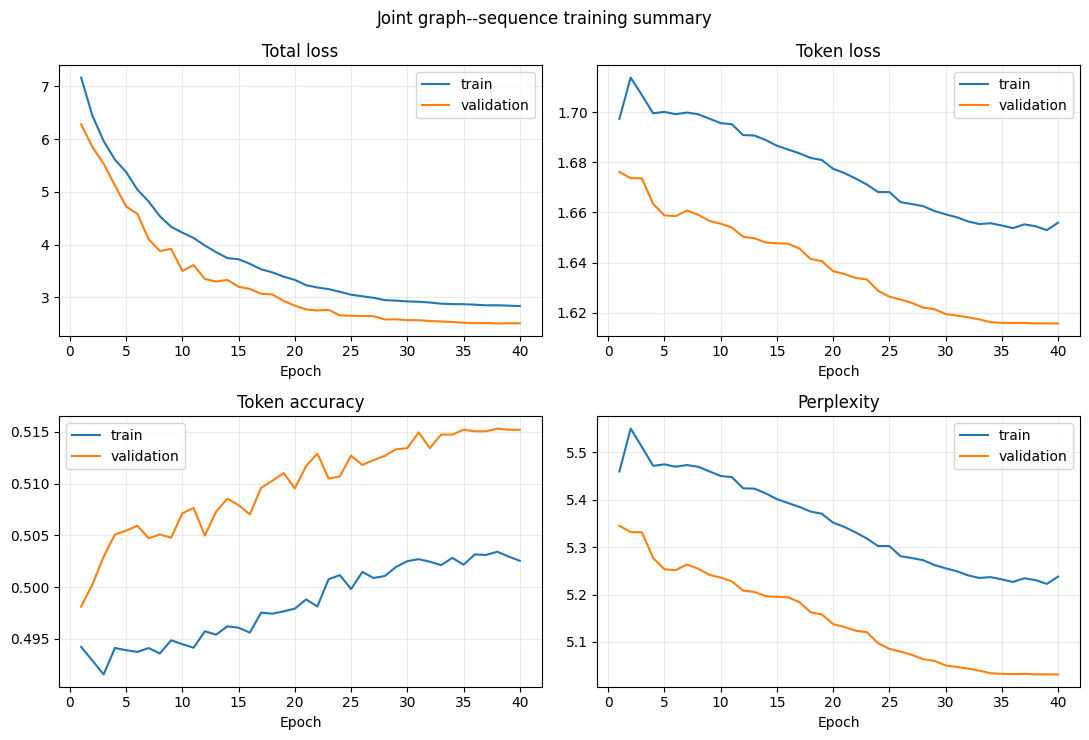

In [15]:
def save_metric_curve(
    frame: pd.DataFrame,
    columns: Sequence[str],
    labels: Sequence[str],
    ylabel: str,
    title: str,
    filename: str,
) -> None:
    plt.figure(figsize=(6.8, 4.3))
    for column, label in zip(columns, labels):
        plt.plot(frame["epoch"], frame[column], marker="o", markersize=3, label=label)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=180)
    plt.show()

save_metric_curve(
    lm_history_df, ["train_token_loss", "val_token_loss"],
    ["train", "validation"], "Token cross-entropy",
    "Language-model warm-up loss", "lm_warmup_loss.png"
)
save_metric_curve(
    lm_history_df, ["train_token_accuracy", "val_token_accuracy"],
    ["train", "validation"], "Non-pad token accuracy",
    "Language-model warm-up token accuracy", "lm_warmup_token_accuracy.png"
)
save_metric_curve(
    lm_history_df, ["train_perplexity", "val_perplexity"],
    ["train", "validation"], "Perplexity",
    "Language-model warm-up perplexity", "lm_warmup_perplexity.png"
)
save_metric_curve(
    joint_history_df, ["train_total_loss", "val_total_loss"],
    ["train", "validation"], "Total loss",
    "Joint-training objective", "joint_total_loss.png"
)
save_metric_curve(
    joint_history_df,
    ["val_token_loss", "val_contrastive_loss", "val_pair_loss"],
    ["token", "contrastive", "positive pair"], "Validation loss",
    "Joint validation loss components", "joint_loss_components.png"
)
save_metric_curve(
    joint_history_df, ["train_token_accuracy", "val_token_accuracy"],
    ["train", "validation"], "Non-pad token accuracy",
    "Joint-training token accuracy", "joint_token_accuracy.png"
)
save_metric_curve(
    joint_history_df, ["train_perplexity", "val_perplexity"],
    ["train", "validation"], "Perplexity",
    "Joint-training perplexity", "joint_perplexity.png"
)
save_metric_curve(
    joint_history_df, ["learning_rate"], ["learning rate"],
    "Learning rate", "Cosine learning-rate schedule",
    "learning_rate_schedule.png"
)

fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
dashboard_specs = [
    ("train_total_loss", "val_total_loss", "Total loss"),
    ("train_token_loss", "val_token_loss", "Token loss"),
    ("train_token_accuracy", "val_token_accuracy", "Token accuracy"),
    ("train_perplexity", "val_perplexity", "Perplexity"),
]
for ax, (train_col, val_col, title) in zip(axes.flat, dashboard_specs):
    ax.plot(joint_history_df.epoch, joint_history_df[train_col], label="train")
    ax.plot(joint_history_df.epoch, joint_history_df[val_col], label="validation")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.25)
    ax.legend()
fig.suptitle("Joint graph--sequence training summary")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "training_curves_summary.png", dpi=180)
plt.show()

## 17. Test-set cross-modal retrieval

The best validation checkpoint is used once to encode the deterministic test set.
Cosine similarities are computed between every graph and every sequence. Metrics
are reported in both directions alongside finite-test-set random baselines.

Encoding:   0%|          | 0/2 [00:00<?, ?it/s]

,metric,value
0,test_size,420.000000
1,graph_to_sequence_top1,0.819048
2,graph_to_sequence_top5,0.990476
3,sequence_to_graph_top1,0.790476
4,sequence_to_graph_top5,0.980952
5,random_top1,0.002381
6,random_top5,0.011905
7,matching_cosine_mean,0.892222
8,matching_cosine_std,0.051037
9,nonmatching_cosine_mean,0.012944


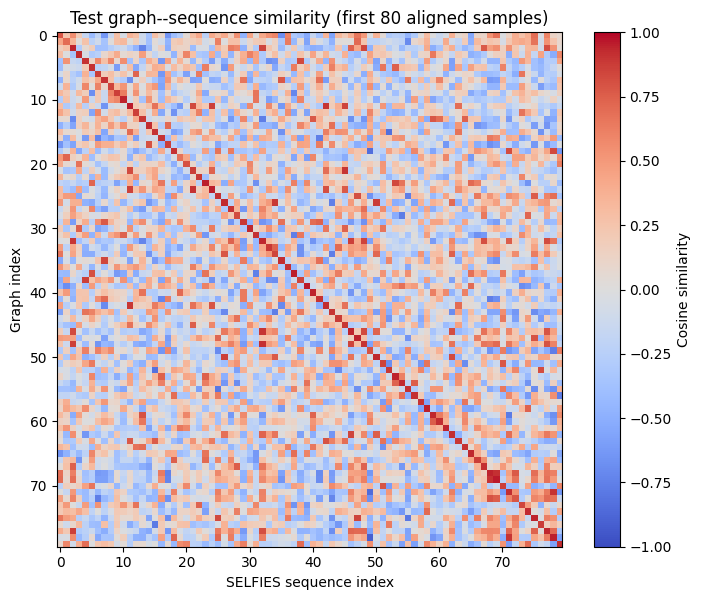

Retrieval evaluation time: 0.592 s


In [16]:
@torch.inference_mode()
def encode_dataset(
    joint_model: JointGraphSequenceModel, loader: DataLoader
) -> Dict[str, Any]:
    joint_model.eval()
    graph_embeddings: List[torch.Tensor] = []
    sequence_embeddings: List[torch.Tensor] = []
    smiles: List[str] = []
    selfies_strings: List[str] = []
    sample_orders: List[int] = []
    for batch in tqdm(loader, leave=False, desc="Encoding"):
        graph_batch, token_ids = move_batch(batch)
        output = joint_model(graph_batch, token_ids)
        graph_embeddings.append(output["graph_projection"].cpu())
        sequence_embeddings.append(output["sequence_projection"].cpu())
        smiles.extend(batch["canonical_smiles"])
        selfies_strings.extend(batch["selfies"])
        sample_orders.extend(batch["sample_order"].tolist())
    return {
        "graph": F.normalize(torch.cat(graph_embeddings), dim=-1),
        "sequence": F.normalize(torch.cat(sequence_embeddings), dim=-1),
        "canonical_smiles": smiles,
        "selfies": selfies_strings,
        "sample_order": sample_orders,
    }

def retrieval_metrics(
    graph_embeddings: torch.Tensor, sequence_embeddings: torch.Tensor
) -> Tuple[Dict[str, float], torch.Tensor]:
    similarity = graph_embeddings @ sequence_embeddings.T
    n = similarity.shape[0]
    labels = torch.arange(n)
    k = min(5, n)
    g2s_top = similarity.topk(k, dim=1).indices
    s2g_top = similarity.T.topk(k, dim=1).indices
    diagonal = similarity.diag()
    if n > 1:
        off_diagonal = similarity[~torch.eye(n, dtype=torch.bool)]
    else:
        off_diagonal = torch.empty(0)
    metrics = {
        "test_size": float(n),
        "graph_to_sequence_top1": float(g2s_top[:, :1].eq(labels[:, None]).any(1).float().mean()),
        "graph_to_sequence_top5": float(g2s_top.eq(labels[:, None]).any(1).float().mean()),
        "sequence_to_graph_top1": float(s2g_top[:, :1].eq(labels[:, None]).any(1).float().mean()),
        "sequence_to_graph_top5": float(s2g_top.eq(labels[:, None]).any(1).float().mean()),
        "random_top1": 1.0 / max(1, n),
        "random_top5": min(5.0 / max(1, n), 1.0),
        "matching_cosine_mean": float(diagonal.mean()),
        "matching_cosine_std": float(diagonal.std(unbiased=False)),
        "nonmatching_cosine_mean": float(off_diagonal.mean()) if off_diagonal.numel() else float("nan"),
        "nonmatching_cosine_std": float(off_diagonal.std(unbiased=False)) if off_diagonal.numel() else float("nan"),
    }
    return metrics, similarity

retrieval_start = time.perf_counter()
test_encodings = encode_dataset(model, loaders["test"])
retrieval_results, test_similarity = retrieval_metrics(
    test_encodings["graph"], test_encodings["sequence"]
)
retrieval_evaluation_seconds = time.perf_counter() - retrieval_start

retrieval_df = pd.DataFrame([
    {"metric": key, "value": value} for key, value in retrieval_results.items()
])
retrieval_df.to_csv(RESULT_DIR / "retrieval_metrics.csv", index=False)
display(retrieval_df)

subset_size = min(80, test_similarity.shape[0])
plt.figure(figsize=(7.2, 6.1))
plt.imshow(test_similarity[:subset_size, :subset_size].numpy(),
           cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(label="Cosine similarity")
plt.xlabel("SELFIES sequence index")
plt.ylabel("Graph index")
plt.title(f"Test graph--sequence similarity (first {subset_size} aligned samples)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "test_similarity_matrix.png", dpi=180)
plt.show()
print(f"Retrieval evaluation time: {retrieval_evaluation_seconds:.3f} s")

## 18. Autoregressive SELFIES generation

Generation begins only with `<bos>` and never receives a ground-truth
continuation. `<pad>`, `<bos>`, and `<unk>` are banned; `<eos>` is additionally
banned for the first five SELFIES symbols. Temperature scaling, top-20 truncation,
and nucleus sampling at 0.95 are applied in that order. Separate deterministic
random streams are used for each temperature.

In [17]:
def sample_next_token(
    logits: torch.Tensor,
    temperature: float,
    generator: torch.Generator,
    allow_eos: bool,
) -> torch.Tensor:
    if temperature <= 0:
        raise ValueError("Sampling temperature must be positive.")
    filtered = logits.float() / temperature
    filtered[:, [pad_id, bos_id, unk_id]] = -torch.inf
    if not allow_eos:
        filtered[:, eos_id] = -torch.inf
    restricted_original = filtered.clone()

    k = min(CFG.top_k, filtered.shape[-1])
    top_values, _ = filtered.topk(k, dim=-1)
    cutoff = top_values[:, -1:].expand_as(filtered)
    filtered = filtered.masked_fill(filtered < cutoff, -torch.inf)

    sorted_logits, sorted_indices = filtered.sort(dim=-1, descending=True)
    sorted_probs = torch.softmax(sorted_logits, dim=-1)
    cumulative = sorted_probs.cumsum(dim=-1)
    remove = cumulative > CFG.top_p
    remove[:, 1:] = remove[:, :-1].clone()
    remove[:, 0] = False
    sorted_logits = sorted_logits.masked_fill(remove, -torch.inf)
    nucleus_logits = torch.full_like(filtered, -torch.inf)
    nucleus_logits.scatter_(1, sorted_indices, sorted_logits)

    probabilities = torch.softmax(nucleus_logits, dim=-1)
    finite_rows = torch.isfinite(probabilities).all(dim=1) & probabilities.sum(dim=1).gt(0)
    output = torch.empty(logits.shape[0], dtype=torch.long, device=logits.device)
    if finite_rows.any():
        output[finite_rows] = torch.multinomial(
            probabilities[finite_rows], 1, generator=generator
        ).squeeze(1)
    if (~finite_rows).any():
        fallback = restricted_original[~finite_rows]
        if not torch.isfinite(fallback).any(dim=1).all():
            raise RuntimeError("No finite allowed token remained after sampling filters.")
        output[~finite_rows] = fallback.argmax(dim=1)
    return output

@torch.inference_mode()
def generate_selfies_batch(
    transformer: CausalSelfiesTransformer,
    num_samples: int,
    temperature: float,
    seed: int,
) -> List[Dict[str, Any]]:
    transformer.eval()
    generated_rows: List[Dict[str, Any]] = []
    generator = torch.Generator(device=DEVICE).manual_seed(seed)
    for batch_start in tqdm(
        range(0, num_samples, CFG.generation_batch_size),
        desc=f"Generate T={temperature}",
        leave=False,
    ):
        batch_n = min(CFG.generation_batch_size, num_samples - batch_start)
        active_ids = torch.arange(batch_n, device=DEVICE)
        active_tokens = torch.full(
            (batch_n, 1), bos_id, dtype=torch.long, device=DEVICE
        )
        completed: Dict[int, Tuple[List[int], bool]] = {}

        for step in range(CFG.max_generation_length):
            _, logits = transformer(active_tokens)
            next_ids = sample_next_token(
                logits[:, -1, :],
                temperature,
                generator,
                allow_eos=(step >= CFG.min_generation_steps_before_eos),
            )
            assert not any(
                token in (pad_id, bos_id, unk_id) for token in next_ids.tolist()
            )
            if step < CFG.min_generation_steps_before_eos:
                assert not next_ids.eq(eos_id).any()
            active_tokens = torch.cat([active_tokens, next_ids[:, None]], dim=1)
            finished = next_ids.eq(eos_id)
            for row_index in finished.nonzero(as_tuple=False).flatten().tolist():
                completed[int(active_ids[row_index])] = (
                    active_tokens[row_index].tolist(), True
                )
            keep = ~finished
            if not keep.any():
                active_ids = active_ids[:0]
                active_tokens = active_tokens[:0]
                break
            active_ids = active_ids[keep]
            active_tokens = active_tokens[keep]

        for row_index in range(active_tokens.shape[0]):
            completed[int(active_ids[row_index])] = (
                active_tokens[row_index].tolist(), False
            )
        for local_id in range(batch_n):
            token_ids, terminated = completed[local_id]
            raw_ids = [
                token for token in token_ids[1:]
                if token not in (eos_id, pad_id)
            ]
            symbols = [id_to_token[token] for token in raw_ids]
            generated_rows.append({
                "temperature": float(temperature),
                "sample_id": batch_start + local_id,
                "generated_token_ids": json.dumps(token_ids),
                "generated_selfies": "".join(symbols),
                "terminated_with_eos": bool(terminated),
                "generated_length": len(raw_ids),
            })
    return generated_rows

generation_start = time.perf_counter()
generated_rows: List[Dict[str, Any]] = []
for temperature_index, temperature in enumerate(CFG.generation_temperatures):
    generated_rows.extend(generate_selfies_batch(
        model.transformer,
        GENERATIONS_PER_TEMPERATURE,
        temperature,
        CFG.seed + 1009 * (temperature_index + 1),
    ))
generation_seconds = time.perf_counter() - generation_start
generated_df = pd.DataFrame(generated_rows)
generated_df.to_csv(RESULT_DIR / "generated_sequences_all.csv", index=False)

assert len(generated_df) == len(CFG.generation_temperatures) * GENERATIONS_PER_TEMPERATURE
assert generated_df.generated_length.ge(CFG.min_generation_steps_before_eos).all()
print(generated_df.groupby("temperature").agg(
    attempted=("sample_id", "size"),
    mean_length=("generated_length", "mean"),
    eos_rate=("terminated_with_eos", "mean"),
))
print(f"Generation time: {generation_seconds:.3f} s")

Generate T=0.8:   0%|          | 0/5 [00:00<?, ?it/s]

Generate T=1.0:   0%|          | 0/5 [00:00<?, ?it/s]

Generate T=1.2:   0%|          | 0/5 [00:00<?, ?it/s]

             attempted  mean_length  eos_rate
temperature                                  
0.8                300    40.800000  1.000000
1.0                300    43.823333  1.000000
1.2                300    43.780000  0.993333
Generation time: 12.842 s


## 19--20. Strict generated-molecule validation and training constraints

Validation records the first failure only and follows the required order:
SELFIES decode, unsanitized RDKit parse, sanitization, connectedness, elements
and dummy atoms, radicals, heavy-atom range, molecular-weight range, formal
charge, and canonicalization. RDKit-valid means that parsing and sanitization
both passed; acceptance requires every stage.

In [18]:
train_records = [r for r in usable_records if r["split"] == "train"]
training_mols = [Chem.MolFromSmiles(r["canonical_smiles"]) for r in train_records]
allowed_elements = sorted({
    atom.GetSymbol() for mol in training_mols for atom in mol.GetAtoms()
})
train_heavy_atoms = np.array([mol.GetNumHeavyAtoms() for mol in training_mols])
train_molecular_weights = np.array([Descriptors.MolWt(mol) for mol in training_mols])
train_abs_charges = np.array([abs(Chem.GetFormalCharge(mol)) for mol in training_mols])
heavy_atom_bounds = np.percentile(train_heavy_atoms, [1, 99])
molecular_weight_bounds = np.percentile(train_molecular_weights, [1, 99])
max_abs_formal_charge = int(train_abs_charges.max())
training_canonical_set = {r["canonical_smiles"] for r in train_records}

training_constraints = {
    "allowed_elements": allowed_elements,
    "heavy_atom_count_percentile_1": float(heavy_atom_bounds[0]),
    "heavy_atom_count_percentile_99": float(heavy_atom_bounds[1]),
    "molecular_weight_percentile_1": float(molecular_weight_bounds[0]),
    "molecular_weight_percentile_99": float(molecular_weight_bounds[1]),
    "maximum_absolute_molecular_formal_charge": max_abs_formal_charge,
    "percentile_interpolation": "NumPy default linear method",
    "training_molecule_count": len(train_records),
}
with open(
    RESULT_DIR / "training_chemical_constraints.json", "w", encoding="utf-8"
) as handle:
    json.dump(training_constraints, handle, indent=2)
print(json.dumps(training_constraints, indent=2))

{
  "allowed_elements": [
    "B",
    "Br",
    "C",
    "Cl",
    "F",
    "I",
    "N",
    "O",
    "P",
    "S",
    "Se",
    "Si"
  ],
  "heavy_atom_count_percentile_1": 11.0,
  "heavy_atom_count_percentile_99": 43.0,
  "molecular_weight_percentile_1": 148.18876,
  "molecular_weight_percentile_99": 616.7506400000002,
  "maximum_absolute_molecular_formal_charge": 1,
  "percentile_interpolation": "NumPy default linear method",
  "training_molecule_count": 3355
}


In [19]:
VALIDATION_STAGES = [
    "selfies_decode",
    "rdkit_parse",
    "rdkit_sanitize",
    "connected_components",
    "elements_and_dummy_atoms",
    "radical_electrons",
    "heavy_atom_range",
    "molecular_weight_range",
    "formal_charge",
    "canonicalization",
]

def reject(
    audit: Dict[str, Any], stage: str, reason: str
) -> Dict[str, Any]:
    audit["first_rejection_stage"] = stage
    audit["first_rejection_reason"] = reason
    audit["accepted"] = False
    return audit

def validate_generated_molecule(row: pd.Series) -> Dict[str, Any]:
    audit: Dict[str, Any] = {
        "temperature": float(row.temperature),
        "sample_id": int(row.sample_id),
        "generated_selfies": row.generated_selfies,
        "decoded_smiles": "",
        "rdkit_valid": False,
        "accepted": False,
        "first_rejection_stage": "",
        "first_rejection_reason": "",
        "canonical_smiles": "",
        "connected_components": np.nan,
        "elements": "",
        "has_dummy_atom": np.nan,
        "has_radical": np.nan,
        "heavy_atom_count": np.nan,
        "molecular_weight": np.nan,
        "formal_charge": np.nan,
    }
    try:
        decoded = sf.decoder(str(row.generated_selfies))
    except Exception as exc:
        return reject(audit, "selfies_decode", f"decode_exception:{type(exc).__name__}")
    if decoded is None or not str(decoded).strip():
        return reject(audit, "selfies_decode", "empty_decoded_smiles")
    audit["decoded_smiles"] = str(decoded)

    try:
        mol = Chem.MolFromSmiles(str(decoded), sanitize=False)
    except Exception as exc:
        return reject(audit, "rdkit_parse", f"parse_exception:{type(exc).__name__}")
    if mol is None:
        return reject(audit, "rdkit_parse", "rdkit_returned_none")
    try:
        Chem.SanitizeMol(mol)
    except Exception as exc:
        return reject(audit, "rdkit_sanitize", f"sanitize_exception:{type(exc).__name__}")
    audit["rdkit_valid"] = True

    fragments = Chem.GetMolFrags(mol)
    audit["connected_components"] = len(fragments)
    if len(fragments) != 1:
        return reject(audit, "connected_components", "multiple_components")

    atomic_numbers = [atom.GetAtomicNum() for atom in mol.GetAtoms()]
    elements = sorted({atom.GetSymbol() for atom in mol.GetAtoms()})
    audit["elements"] = ";".join(elements)
    audit["has_dummy_atom"] = any(number == 0 for number in atomic_numbers)
    unsupported = sorted(set(elements).difference(allowed_elements))
    if audit["has_dummy_atom"] or unsupported:
        reason = (
            "dummy_atom" if audit["has_dummy_atom"]
            else "unsupported_elements:" + ",".join(unsupported)
        )
        return reject(audit, "elements_and_dummy_atoms", reason)

    audit["has_radical"] = any(
        atom.GetNumRadicalElectrons() != 0 for atom in mol.GetAtoms()
    )
    if audit["has_radical"]:
        return reject(audit, "radical_electrons", "nonzero_radical_electrons")

    heavy_atoms = int(mol.GetNumHeavyAtoms())
    molecular_weight = float(Descriptors.MolWt(mol))
    formal_charge = int(Chem.GetFormalCharge(mol))
    audit["heavy_atom_count"] = heavy_atoms
    audit["molecular_weight"] = molecular_weight
    audit["formal_charge"] = formal_charge
    if not (heavy_atom_bounds[0] <= heavy_atoms <= heavy_atom_bounds[1]):
        return reject(audit, "heavy_atom_range", "outside_training_1st_99th_percentiles")
    if not (
        molecular_weight_bounds[0]
        <= molecular_weight
        <= molecular_weight_bounds[1]
    ):
        return reject(
            audit, "molecular_weight_range",
            "outside_training_1st_99th_percentiles"
        )
    if abs(formal_charge) > max_abs_formal_charge:
        return reject(audit, "formal_charge", "exceeds_training_maximum_absolute_charge")

    try:
        canonical = Chem.MolToSmiles(
            mol, canonical=True, isomericSmiles=True
        )
    except Exception as exc:
        return reject(
            audit, "canonicalization",
            f"canonicalization_exception:{type(exc).__name__}"
        )
    if not canonical:
        return reject(audit, "canonicalization", "empty_canonical_smiles")
    audit["canonical_smiles"] = canonical
    audit["accepted"] = True
    return audit

validation_start = time.perf_counter()
validation_rows = [
    validate_generated_molecule(row)
    for _, row in tqdm(
        generated_df.iterrows(), total=len(generated_df), desc="Validating"
    )
]
validation_seconds = time.perf_counter() - validation_start
validation_df = pd.DataFrame(validation_rows)
validation_df.to_csv(RESULT_DIR / "generated_validation_audit.csv", index=False)

assert validation_df.groupby("temperature").size().eq(
    GENERATIONS_PER_TEMPERATURE
).all()
assert (
    validation_df["accepted"]
    <= validation_df["rdkit_valid"]
).all()
accepted_canonical = validation_df.loc[
    validation_df.accepted, "canonical_smiles"
]
assert accepted_canonical.ne("").all()
print(f"Validation time: {validation_seconds:.3f} s")
display(validation_df.head())

Validating:   0%|          | 0/900 [00:00<?, ?it/s]

Validation time: 0.373 s


,temperature,sample_id,generated_selfies,decoded_smiles,rdkit_valid,accepted,first_rejection_stage,first_rejection_reason,canonical_smiles,connected_components,elements,has_dummy_atom,has_radical,heavy_atom_count,molecular_weight,formal_charge
0,0.8,0,[C][N][C][C][C][=C][Branch2][Ring1][Ring2][=N]...,C1NCCC=C(NC(=O)NC=CC2=CC=CC=C2C=C1)C=O,True,True,,,O=CC1=CCCNCC=Cc2ccccc2C=CNC(=O)N1,1,C;N;O,False,False,22.0,297.358,0.0
1,0.8,1,[N][C][=C][C][=C][C][=C][Ring1][#Branch1][O][C...,N1C2=CC=CC=C1OC(=O)NC=C2C=CC3=CCC=CC=C3,True,True,,,O=c1[nH]cc(C=CC2=CCC=CC=C2)c2[nH]c(o1)=CC=CC=2,1,C;N;O,False,False,22.0,292.338,0.0
2,0.8,2,[C][C][Branch1][C][C][C][N][C][=C][C][Branch1]...,C1C(C)CNC=CC(Cl)=C1CCCC,True,True,,,CCCCC1=C(Cl)C=CNCC(C)C1,1,C;Cl;N,False,False,14.0,213.752,0.0
3,0.8,3,[O][=C][Branch1][S][C][=C][C][=C][Ring1][=Bran...,O=C(C=CC1=CCC=CC=C1CCl)NCCCCOCCNC2=CCCCO2,True,True,,,O=C(C=CC1=CCC=CC=C1CCl)NCCCCOCCNC1=CCCCO1,1,C;Cl;N;O,False,False,28.0,406.954,0.0
4,0.8,4,[C][C][=C][C][=C][Ring1][Branch1][C][C][C][C][...,C1C=CC=C1CCCCN=C=C2C(=O)CC=C2C=C,True,True,,,C=CC1=CCC(=O)C1=C=NCCCCC1=CC=CC1,1,C;N;O,False,False,19.0,253.345,0.0


## 20--22. Novelty, fingerprints, representation analysis, and examples

Exact novelty uses canonical accepted structures. Morgan fingerprints use radius
two and 2,048 bits; structural novelty additionally requires maximum training-set
Tanimoto similarity below 0.85. QED is reported only as a descriptive statistic,
never as evidence of safety, usefulness, synthesizability, or activity.

In [20]:
fingerprint_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=CFG.fingerprint_radius, fpSize=CFG.fingerprint_bits
)

def compute_morgan_fingerprint(mol: Chem.Mol):
    return fingerprint_generator.GetFingerprint(mol)

training_fingerprints = [
    compute_morgan_fingerprint(mol) for mol in training_mols
]

def maximum_training_tanimoto(canonical_smiles: str) -> float:
    mol = Chem.MolFromSmiles(canonical_smiles)
    if mol is None or not training_fingerprints:
        return float("nan")
    fingerprint = compute_morgan_fingerprint(mol)
    similarities = DataStructs.BulkTanimotoSimilarity(
        fingerprint, training_fingerprints
    )
    return float(max(similarities)) if similarities else float("nan")

# Compute each unique accepted structure only once, then map to all samples.
unique_accepted_smiles = sorted(set(accepted_canonical))
max_tanimoto_by_smiles = {
    smiles: maximum_training_tanimoto(smiles)
    for smiles in tqdm(unique_accepted_smiles, desc="Fingerprint novelty")
}
validation_df["max_training_tanimoto"] = validation_df["canonical_smiles"].map(
    max_tanimoto_by_smiles
)
validation_df["exact_novel"] = (
    validation_df["accepted"]
    & ~validation_df["canonical_smiles"].isin(training_canonical_set)
)
validation_df["structurally_novel"] = (
    validation_df["exact_novel"]
    & validation_df["max_training_tanimoto"].lt(
        CFG.structural_novelty_threshold
    )
)
validation_df["qed"] = np.nan
for index in validation_df.index[validation_df.accepted]:
    mol = Chem.MolFromSmiles(validation_df.at[index, "canonical_smiles"])
    validation_df.at[index, "qed"] = float(QED.qed(mol))
validation_df.to_csv(RESULT_DIR / "generated_validation_audit.csv", index=False)

generation_metric_rows: List[Dict[str, Any]] = []
for temperature in CFG.generation_temperatures:
    raw_subset = generated_df[generated_df.temperature == temperature]
    subset = validation_df[validation_df.temperature == temperature]
    attempted = len(subset)
    rdkit_valid_count = int(subset.rdkit_valid.sum())
    accepted_count = int(subset.accepted.sum())
    accepted_subset = subset[subset.accepted]
    unique_subset = accepted_subset.drop_duplicates("canonical_smiles")
    unique_count = len(unique_subset)
    novel_subset = unique_subset[
        ~unique_subset.canonical_smiles.isin(training_canonical_set)
    ]
    novel_count = len(novel_subset)
    structural_count = int(
        novel_subset.max_training_tanimoto.lt(
            CFG.structural_novelty_threshold
        ).sum()
    )
    early_eos_count = int(
        (
            raw_subset.terminated_with_eos
            & raw_subset.generated_length.lt(CFG.max_generation_length)
        ).sum()
    )
    max_length_count = int(
        raw_subset.generated_length.ge(CFG.max_generation_length).sum()
    )
    generation_metric_rows.append({
        "temperature": temperature,
        "attempted_count": attempted,
        "rdkit_valid_count": rdkit_valid_count,
        "rdkit_valid_rate": rdkit_valid_count / max(1, attempted),
        "acceptance_count": accepted_count,
        "acceptance_rate": accepted_count / max(1, attempted),
        "unique_accepted_count": unique_count,
        "uniqueness_denominator_accepted": accepted_count,
        "uniqueness_rate": unique_count / max(1, accepted_count) if accepted_count else 0.0,
        "exact_novel_count": novel_count,
        "exact_novelty_denominator_unique_accepted": unique_count,
        "exact_novelty_rate": novel_count / max(1, unique_count) if unique_count else 0.0,
        "structurally_novel_count": structural_count,
        "structural_novelty_denominator_unique_exact_novel": novel_count,
        "structural_novelty_rate": structural_count / max(1, novel_count) if novel_count else 0.0,
        "mean_max_training_tanimoto_novel": float(novel_subset.max_training_tanimoto.mean()) if novel_count else np.nan,
        "median_max_training_tanimoto_novel": float(novel_subset.max_training_tanimoto.median()) if novel_count else np.nan,
        "mean_qed_accepted": float(accepted_subset.qed.mean()) if accepted_count else np.nan,
        "mean_generated_length": float(raw_subset.generated_length.mean()),
        "early_eos_count": early_eos_count,
        "early_eos_rate": early_eos_count / max(1, attempted),
        "maximum_length_count": max_length_count,
        "maximum_length_rate": max_length_count / max(1, attempted),
    })

generation_metrics_df = pd.DataFrame(generation_metric_rows)
generation_metrics_df.to_csv(
    RESULT_DIR / "generation_metrics_by_temperature.csv", index=False
)
display(generation_metrics_df)

Fingerprint novelty:   0%|          | 0/706 [00:00<?, ?it/s]

,temperature,attempted_count,rdkit_valid_count,rdkit_valid_rate,acceptance_count,acceptance_rate,unique_accepted_count,uniqueness_denominator_accepted,uniqueness_rate,exact_novel_count,...,structural_novelty_denominator_unique_exact_novel,structural_novelty_rate,mean_max_training_tanimoto_novel,median_max_training_tanimoto_novel,mean_qed_accepted,mean_generated_length,early_eos_count,early_eos_rate,maximum_length_count,maximum_length_rate
0,0.8,300,300,1.0,273,0.910000,273,273,1.0,273,...,273,1.0,0.188542,0.177778,0.518744,40.800000,300,1.000000,0,0.000000
1,1.0,300,300,1.0,250,0.833333,250,250,1.0,250,...,250,1.0,0.172169,0.163785,0.480105,43.823333,300,1.000000,0,0.000000
2,1.2,300,300,1.0,183,0.610000,183,183,1.0,183,...,183,1.0,0.163266,0.153846,0.420345,43.780000,298,0.993333,2,0.006667


,temperature,stage,first_failure_count,cumulative_pass_count,attempted_count
0,0.8,selfies_decode,0,300,300
1,0.8,rdkit_parse,0,300,300
2,0.8,rdkit_sanitize,0,300,300
3,0.8,connected_components,0,300,300
4,0.8,elements_and_dummy_atoms,0,300,300
5,0.8,radical_electrons,0,300,300
6,0.8,heavy_atom_range,25,275,300
7,0.8,molecular_weight_range,2,273,300
8,0.8,formal_charge,0,273,300
9,0.8,canonicalization,0,273,300


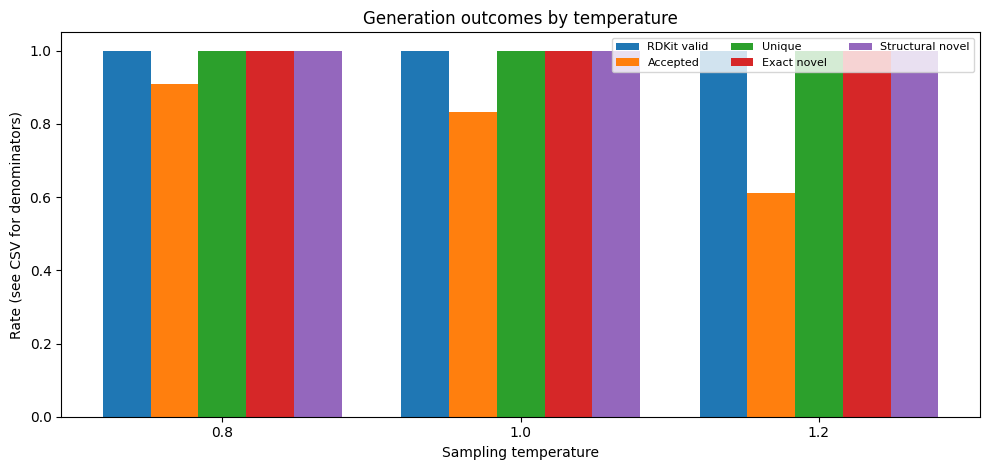

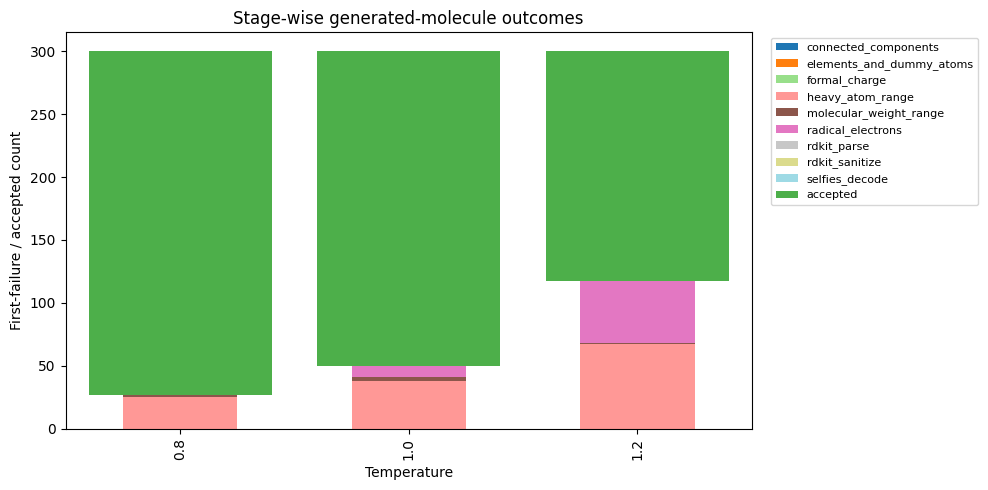

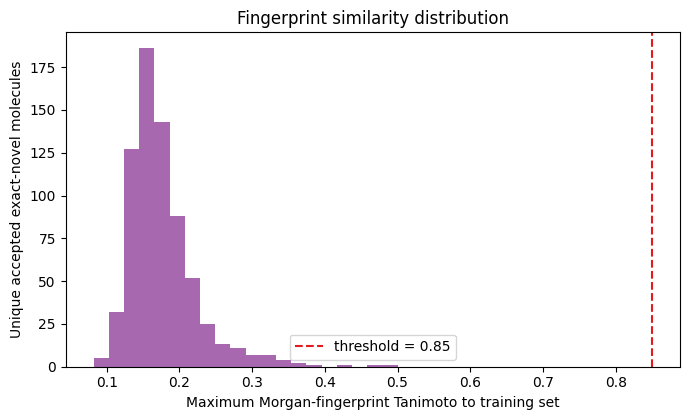

In [21]:
rejection_rows: List[Dict[str, Any]] = []
for temperature in CFG.generation_temperatures:
    subset = validation_df[validation_df.temperature == temperature]
    attempted = len(subset)
    cumulative_pass = attempted
    for stage in VALIDATION_STAGES:
        rejected_here = int((subset.first_rejection_stage == stage).sum())
        cumulative_pass -= rejected_here
        rejection_rows.append({
            "temperature": temperature,
            "stage": stage,
            "first_failure_count": rejected_here,
            "cumulative_pass_count": cumulative_pass,
            "attempted_count": attempted,
        })
    rejection_rows.append({
        "temperature": temperature,
        "stage": "accepted",
        "first_failure_count": int(subset.accepted.sum()),
        "cumulative_pass_count": int(subset.accepted.sum()),
        "attempted_count": attempted,
    })
    assert (
        sum(
            row["first_failure_count"]
            for row in rejection_rows
            if row["temperature"] == temperature and row["stage"] != "accepted"
        )
        + int(subset.accepted.sum())
        == attempted
    )

rejection_df = pd.DataFrame(rejection_rows)
rejection_df.to_csv(RESULT_DIR / "rejection_counts_by_stage.csv", index=False)
display(rejection_df)

plot_metrics = [
    ("rdkit_valid_rate", "RDKit valid"),
    ("acceptance_rate", "Accepted"),
    ("uniqueness_rate", "Unique"),
    ("exact_novelty_rate", "Exact novel"),
    ("structural_novelty_rate", "Structural novel"),
]
x = np.arange(len(CFG.generation_temperatures))
width = 0.16
plt.figure(figsize=(10, 4.8))
for offset, (column, label) in enumerate(plot_metrics):
    plt.bar(
        x + (offset - 2) * width,
        generation_metrics_df[column],
        width,
        label=label,
    )
plt.xticks(x, [str(t) for t in CFG.generation_temperatures])
plt.ylim(0, 1.05)
plt.xlabel("Sampling temperature")
plt.ylabel("Rate (see CSV for denominators)")
plt.title("Generation outcomes by temperature")
plt.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "generation_temperature_comparison.png", dpi=180)
plt.show()

pivot = rejection_df[
    ~rejection_df.stage.isin(["canonicalization", "accepted"])
].pivot(index="temperature", columns="stage", values="first_failure_count").fillna(0)
ax = pivot.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="tab20")
accepted_by_temp = rejection_df[rejection_df.stage == "accepted"].set_index(
    "temperature"
)["first_failure_count"]
ax.bar(
    np.arange(len(pivot)), accepted_by_temp.reindex(pivot.index).values,
    bottom=pivot.sum(axis=1).values, label="accepted", color="#4daf4a"
)
ax.set_xlabel("Temperature")
ax.set_ylabel("First-failure / accepted count")
ax.set_title("Stage-wise generated-molecule outcomes")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "generation_rejection_counts.png", dpi=180)
plt.show()

novel_similarities = (
    validation_df[validation_df.exact_novel]
    .drop_duplicates("canonical_smiles")
    .max_training_tanimoto.dropna()
)
plt.figure(figsize=(7, 4.3))
if len(novel_similarities):
    plt.hist(novel_similarities, bins=20, color="#984ea3", alpha=0.85)
    plt.axvline(
        CFG.structural_novelty_threshold,
        color="#e41a1c", linestyle="--",
        label=f"threshold = {CFG.structural_novelty_threshold}"
    )
    plt.legend()
else:
    plt.text(
        0.5, 0.5, "No accepted exact-novel molecules in this run",
        ha="center", va="center", transform=plt.gca().transAxes
    )
plt.xlabel("Maximum Morgan-fingerprint Tanimoto to training set")
plt.ylabel("Unique accepted exact-novel molecules")
plt.title("Fingerprint similarity distribution")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "fingerprint_similarity_distribution.png", dpi=180)
plt.show()

In [22]:
@torch.inference_mode()
def encode_generated_novel(
    rows: pd.DataFrame,
) -> Tuple[pd.DataFrame, torch.Tensor, torch.Tensor]:
    if rows.empty:
        return rows.copy(), torch.empty((0, CFG.projection_dim)), torch.empty((0, CFG.projection_dim))
    samples = []
    kept_indices = []
    for frame_index, row in rows.iterrows():
        try:
            graph = canonical_smiles_to_graph(row.canonical_smiles)
            symbols = list(sf.split_selfies(row.generated_selfies))
            token_ids = torch.tensor(
                encode_selfies_tokens(symbols), dtype=torch.long
            )
        except Exception:
            continue
        samples.append({
            "graph": graph,
            "token_ids": token_ids,
            "canonical_smiles": row.canonical_smiles,
            "selfies": row.generated_selfies,
            "target": float("nan"),
            "split": "generated",
            "original_index": -1,
            "sample_order": int(graph.sample_order.item()),
        })
        kept_indices.append(frame_index)
    if not samples:
        return rows.iloc[0:0].copy(), torch.empty((0, CFG.projection_dim)), torch.empty((0, CFG.projection_dim))

    encoded_graphs, encoded_sequences = [], []
    for start in range(0, len(samples), CFG.batch_size):
        batch = paired_collate_fn(samples[start:start + CFG.batch_size])
        graph_batch, token_ids = move_batch(batch)
        output = model(graph_batch, token_ids)
        encoded_graphs.append(output["graph_projection"].cpu())
        encoded_sequences.append(output["sequence_projection"].cpu())
    return (
        rows.loc[kept_indices].reset_index(drop=True),
        F.normalize(torch.cat(encoded_graphs), dim=-1),
        F.normalize(torch.cat(encoded_sequences), dim=-1),
    )

accepted_novel_unique = (
    validation_df[validation_df.exact_novel]
    .sort_values(["temperature", "sample_id"])
    .drop_duplicates("canonical_smiles")
)
encoded_novel_df, generated_graph_embeddings, generated_sequence_embeddings = (
    encode_generated_novel(accepted_novel_unique)
)

train_encodings = encode_dataset(model, loaders["train"])
train_combined = F.normalize(
    train_encodings["graph"] + train_encodings["sequence"], dim=-1
)
generated_combined = F.normalize(
    generated_graph_embeddings + generated_sequence_embeddings, dim=-1
) if len(encoded_novel_df) else torch.empty((0, CFG.projection_dim))

neighbor_rows: List[Dict[str, Any]] = []
if len(encoded_novel_df):
    embedding_similarity = generated_combined @ train_combined.T
    nearest_values, nearest_indices = embedding_similarity.max(dim=1)
    compatibility = (
        generated_graph_embeddings * generated_sequence_embeddings
    ).sum(dim=1)
    for index, row in encoded_novel_df.iterrows():
        nearest_index = int(nearest_indices[index])
        neighbor_rows.append({
            "generated_canonical_smiles": row.canonical_smiles,
            "generated_selfies": row.generated_selfies,
            "temperature": float(row.temperature),
            "graph_sequence_cosine": float(compatibility[index]),
            "nearest_training_canonical_smiles": train_encodings[
                "canonical_smiles"
            ][nearest_index],
            "nearest_embedding_cosine": float(nearest_values[index]),
            "maximum_fingerprint_tanimoto": float(row.max_training_tanimoto),
            "qed": float(row.qed),
            "heavy_atom_count": int(row.heavy_atom_count),
            "molecular_weight": float(row.molecular_weight),
        })

nearest_columns = [
    "generated_canonical_smiles", "generated_selfies", "temperature",
    "graph_sequence_cosine", "nearest_training_canonical_smiles",
    "nearest_embedding_cosine", "maximum_fingerprint_tanimoto", "qed",
    "heavy_atom_count", "molecular_weight",
]
generated_neighbors_df = pd.DataFrame(neighbor_rows, columns=nearest_columns)
generated_neighbors_df = generated_neighbors_df.sort_values(
    ["graph_sequence_cosine", "maximum_fingerprint_tanimoto"],
    ascending=[False, True],
) if len(generated_neighbors_df) else generated_neighbors_df
generated_neighbors_df.to_csv(
    RESULT_DIR / "generated_nearest_neighbors.csv", index=False
)
print(
    f"Accepted exact-novel structures encoded: {len(generated_neighbors_df)}; "
    f"showing up to 10 below."
)
display(generated_neighbors_df.head(10))

Encoding:   0%|          | 0/14 [00:00<?, ?it/s]

Accepted exact-novel structures encoded: 706; showing up to 10 below.


,generated_canonical_smiles,generated_selfies,temperature,graph_sequence_cosine,nearest_training_canonical_smiles,nearest_embedding_cosine,maximum_fingerprint_tanimoto,qed,heavy_atom_count,molecular_weight
276,CC(=O)Nc1cc(=O)c2c3ccc(cc[nH]ccc1=2)cn3,[C][C][=Branch1][C][=O][N][C][=C][C][=Branch1]...,1.0,0.949191,CNC(=O)c1ccc2c(=O)cc(-c3cccnc3)[nH]c2c1,0.965663,0.280000,0.716524,21,279.299
8,CC(N)CCCCc1c2cccccccc1-2,[C][C][Branch1][C][N][C][C][C][C][C][=C][Branc...,0.8,0.928432,CC(C)COCC(CN(Cc1ccccc1)c1ccccc1)N1CCCC1,0.969306,0.315789,0.771336,17,227.351
264,Nc1cc2ccc1[nH]ccc1c3ccc(cc3)c21,[N][C][=C][C][=C][C][=C][Ring1][=Branch1][N][C...,0.8,0.919826,c1ccc(-c2cn3ccccc3n2)cc1,0.954176,0.333333,0.441018,18,232.286
50,CC1CC2C=C3C4=Cc5c(ccc6c(cccc56)OCN5CNNCC125)C43,[C][C][=C][C][=C][Ring1][#Branch1][C][=C][C][=...,0.8,0.906198,CN1CC=CCC(c2cc3ccccc3o2)C1,0.910007,0.181818,0.757960,27,357.457
378,COc1cnc(O)cccsc2cccc1-2,[C][O][C][=C][C][=C][C][=C][Ring1][Branch1][S]...,1.0,0.896088,COc1ccc(-c2c(-c3ccc(O)cc3O)n[nH]c2C)cc1,0.948341,0.307692,0.822624,16,233.292
213,O=Cc1c2ccc3c4cc(cc13)C(=C2)Oc1ccccc1C=CN4,[O][=C][C][=C][Branch2][Ring1][#Branch2][C][=C...,0.8,0.893304,O=c1cc(-c2cccnc2)[nH]c2cc(Cc3ccccc3)ccc12,0.942190,0.186441,0.646941,24,311.340
239,CNC(=O)C=C1NCC(C)CCCNC(C)C23CCCCC1N2C3,[C][N][C][=Branch1][C][=O][C][=C][Branch1][#C]...,0.8,0.890439,Cc1sc(CN2CCNCC2)cc1C(=O)NCC12CC3CC(CC(C3)C1)C2,0.966909,0.212121,0.503699,24,334.508
69,CC(=O)NC=Cc1ccncc1,[C][C][=Branch1][C][=O][N][C][=C][C][=C][C][=N...,0.8,0.888523,CC(=O)Nc1ccccn1,0.906434,0.342857,0.709269,12,162.192
119,CC(=O)NCCC12CCCN3C(c4ccccc4C=O)=CC=CNCCC1C3C2,[O][=C][Branch1][C][C][N][C][C][C][Branch1][C]...,0.8,0.881044,CCC(=O)NCC[C@@H]1CCc2ccc3c(c21)CCO3,0.884049,0.228261,0.753477,29,393.531
77,CC=C(C)NC(=O)C=CC=C1COCC(C)CCN(C)C1=O,[C][C][=C][Branch1][C][C][N][C][=Branch1][C][=...,0.8,0.872457,CCCC(=O)Nc1ccc(OCC(O)CNC(C)C)c(C(C)=O)c1,0.880552,0.204545,0.811663,22,306.406


In [23]:
# Prefer structurally novel structures for the molecule grid, then lower
# fingerprint similarity, with deterministic temperature/sample tie-breaking.
grid_candidates = (
    accepted_novel_unique
    .sort_values(
        ["structurally_novel", "max_training_tanimoto", "temperature", "sample_id"],
        ascending=[False, True, True, True],
    )
    .head(20)
)
grid_mols, grid_legends = [], []
for number, (_, row) in enumerate(grid_candidates.iterrows(), start=1):
    mol = Chem.MolFromSmiles(row.canonical_smiles)
    if mol is not None:
        grid_mols.append(mol)
        grid_legends.append(
            f"{number}. T={row.temperature:.1f}; max Tan={row.max_training_tanimoto:.2f}"
        )
if grid_mols:
    grid_image = Draw.MolsToGridImage(
        grid_mols,
        molsPerRow=4,
        subImgSize=(280, 230),
        legends=grid_legends,
        useSVG=False,
    )
    grid_path = FIGURE_DIR / "accepted_novel_molecules_grid.png"
    if hasattr(grid_image, "save"):
        grid_image.save(grid_path)
    elif hasattr(grid_image, "data"):
        grid_path.write_bytes(grid_image.data)
    else:
        raise TypeError(
            f"Unsupported RDKit grid image return type: {type(grid_image)}"
        )
else:
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.axis("off")
    ax.text(
        0.5, 0.5,
        "No accepted exact-novel molecule was available in this run.",
        ha="center", va="center", fontsize=12
    )
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "accepted_novel_molecules_grid.png", dpi=180)
    plt.close(fig)
print(f"Molecules displayed in grid: {len(grid_mols)}")

accepted_examples = (
    validation_df[validation_df.accepted]
    .sort_values(["temperature", "sample_id"])
    .head(6)
    .assign(example_type="accepted")
)
rejected_examples = (
    validation_df[~validation_df.accepted]
    .sort_values(["first_rejection_stage", "temperature", "sample_id"])
    .drop_duplicates("first_rejection_stage")
    .head(8)
    .assign(example_type="rejected")
)
example_columns = [
    "example_type", "temperature", "sample_id", "generated_selfies",
    "decoded_smiles", "canonical_smiles", "accepted",
    "first_rejection_stage", "first_rejection_reason",
]
examples_df = pd.concat(
    [accepted_examples, rejected_examples], ignore_index=True
).reindex(columns=example_columns)
examples_df.to_csv(
    RESULT_DIR / "generated_examples_accepted_rejected.csv", index=False
)
display(examples_df)

Molecules displayed in grid: 20


,example_type,temperature,sample_id,generated_selfies,decoded_smiles,canonical_smiles,accepted,first_rejection_stage,first_rejection_reason
0,accepted,0.8,0,[C][N][C][C][C][=C][Branch2][Ring1][Ring2][=N]...,C1NCCC=C(NC(=O)NC=CC2=CC=CC=C2C=C1)C=O,O=CC1=CCCNCC=Cc2ccccc2C=CNC(=O)N1,True,,
1,accepted,0.8,1,[N][C][=C][C][=C][C][=C][Ring1][#Branch1][O][C...,N1C2=CC=CC=C1OC(=O)NC=C2C=CC3=CCC=CC=C3,O=c1[nH]cc(C=CC2=CCC=CC=C2)c2[nH]c(o1)=CC=CC=2,True,,
2,accepted,0.8,2,[C][C][Branch1][C][C][C][N][C][=C][C][Branch1]...,C1C(C)CNC=CC(Cl)=C1CCCC,CCCCC1=C(Cl)C=CNCC(C)C1,True,,
3,accepted,0.8,3,[O][=C][Branch1][S][C][=C][C][=C][Ring1][=Bran...,O=C(C=CC1=CCC=CC=C1CCl)NCCCCOCCNC2=CCCCO2,O=C(C=CC1=CCC=CC=C1CCl)NCCCCOCCNC1=CCCCO1,True,,
4,accepted,0.8,4,[C][C][=C][C][=C][Ring1][Branch1][C][C][C][C][...,C1C=CC=C1CCCCN=C=C2C(=O)CC=C2C=C,C=CC1=CCC(=O)C1=C=NCCCCC1=CC=CC1,True,,
5,accepted,0.8,5,[N][C][=Branch1][C][=O][C][=C][C][=C][C][=C][R...,N1C(=O)C=CC=CC=CC=C(F)N1,O=C1C=CC=CC=CC=C(F)NN1,True,,
6,rejected,0.8,17,[C][C][=C][C][=C][C][=C][Ring1][=Branch1][C][=...,CC1=CC=CC=C1C=O,,False,heavy_atom_range,outside_training_1st_99th_percentiles
7,rejected,0.8,285,[C][C][=C][C][=C][C][=C][Ring1][=Branch1][C][=...,CC1=CC2=CC=C1C=C2C=O,,False,molecular_weight_range,outside_training_1st_99th_percentiles
8,rejected,1.0,21,[O][=C][Branch1][C][C@@H1][Branch1][C][N][C][C...,O=C([C@@H1])CNCC(N)(CC)C(F)C=CCF,,False,radical_electrons,nonzero_radical_electrons


## 23. Runtime and final measured summary

Installation and initial dataset download/load are listed separately and excluded
from the experiment total. Every printed value is derived from this execution.

In [24]:
total_experiment_seconds = (
    dataset_preparation_seconds
    + lm_warmup_seconds
    + joint_training_seconds
    + retrieval_evaluation_seconds
    + generation_seconds
    + validation_seconds
)
runtime_rows = [
    {"phase": "package_installation", "seconds": np.nan, "included_in_experiment_total": False,
     "note": "Not timed inside notebook; dependencies are installed before execution."},
    {"phase": "dataset_download_and_load", "seconds": dataset_download_and_load_seconds,
     "included_in_experiment_total": False,
     "note": f"Raw file preexisted={raw_preexisted}; excluded by assignment."},
    {"phase": "dataset_preparation", "seconds": dataset_preparation_seconds,
     "included_in_experiment_total": True, "note": "Cleaning through paired loaders."},
    {"phase": "language_model_warmup", "seconds": lm_warmup_seconds,
     "included_in_experiment_total": True, "note": f"{WARMUP_EPOCHS} epochs."},
    {"phase": "joint_training", "seconds": joint_training_seconds,
     "included_in_experiment_total": True,
     "note": f"{len(joint_history_df)} epochs executed."},
    {"phase": "retrieval_evaluation", "seconds": retrieval_evaluation_seconds,
     "included_in_experiment_total": True, "note": "Best checkpoint, complete test set."},
    {"phase": "generation", "seconds": generation_seconds,
     "included_in_experiment_total": True,
     "note": f"{len(generated_df)} total attempts."},
    {"phase": "validation", "seconds": validation_seconds,
     "included_in_experiment_total": True, "note": "Strict staged RDKit pipeline."},
    {"phase": "total_excluding_installation_and_download", "seconds": total_experiment_seconds,
     "included_in_experiment_total": True, "note": "Sum of required experiment phases."},
]
runtime_df = pd.DataFrame(runtime_rows)
runtime_df.to_csv(RESULT_DIR / "runtime_summary.csv", index=False)

total_unique_accepted = validation_df[validation_df.accepted].canonical_smiles.nunique()
total_unique_novel = (
    validation_df[validation_df.exact_novel].canonical_smiles.nunique()
)
total_unique_structural = (
    validation_df[validation_df.structurally_novel].canonical_smiles.nunique()
)

print(f'''
Dataset
-------
Run mode: {RUN_MODE}
Original molecules: {len(raw_dataset)}
Invalid/removed: {int((audit_df.cleaning_status == 'removed').sum())}
Canonical duplicates: {int((audit_df.removal_reason == 'duplicate_canonical').sum())}
Usable molecules: {len(usable_records)}
Train/validation/test sizes: {len(datasets['train'])}/{len(datasets['val'])}/{len(datasets['test'])}
Vocabulary size: {len(vocabulary_tokens)}
Average atom count: {dataset_stats['average_atom_count']:.3f}
Average undirected bond count: {dataset_stats['average_undirected_bond_count']:.3f}
SELFIES length min/mean/max: {lengths.min()}/{lengths.mean():.3f}/{lengths.max()}

Training
--------
Best warm-up epoch: {best_warmup_epoch}
Best joint epoch: {best_joint_epoch}
Best validation token loss: {best_val_metrics['token_loss']:.6f}
Best validation total loss: {best_val_metrics['total_loss']:.6f}
Final validation token accuracy (best checkpoint): {best_val_metrics['token_accuracy']:.6f}
Final validation perplexity (best checkpoint): {best_val_metrics['perplexity']:.6f}
Warm-up runtime: {lm_warmup_seconds:.3f} s
Joint-training runtime: {joint_training_seconds:.3f} s

Retrieval
---------
Graph->sequence top-1/top-5: {retrieval_results['graph_to_sequence_top1']:.6f}/{retrieval_results['graph_to_sequence_top5']:.6f}
Sequence->graph top-1/top-5: {retrieval_results['sequence_to_graph_top1']:.6f}/{retrieval_results['sequence_to_graph_top5']:.6f}
Random top-1/top-5: {retrieval_results['random_top1']:.6f}/{retrieval_results['random_top5']:.6f}
Mean matching/nonmatching cosine: {retrieval_results['matching_cosine_mean']:.6f}/{retrieval_results['nonmatching_cosine_mean']:.6f}

Generation
----------
Attempts per temperature: {GENERATIONS_PER_TEMPERATURE}
Total accepted unique molecules: {total_unique_accepted}
Total accepted novel molecules: {total_unique_novel}
Total structurally novel molecules: {total_unique_structural}
Number displayed in molecule grid: {len(grid_mols)}

Files
-----
Notebook: molecular_gcn_transformer.ipynb
Report: report.tex / report.pdf when compilation succeeds
Figures directory: {FIGURE_DIR}
Results directory: {RESULT_DIR}
Best checkpoint: {CHECKPOINT_DIR / 'best_joint_model.pt'}
''')
for _, row in generation_metrics_df.iterrows():
    print(
        f"T={row.temperature:.1f}: valid {int(row.rdkit_valid_count)}/{int(row.attempted_count)}, "
        f"accepted {int(row.acceptance_count)}/{int(row.attempted_count)}, "
        f"unique {int(row.unique_accepted_count)}/{int(row.uniqueness_denominator_accepted)}, "
        f"exact novel {int(row.exact_novel_count)}/{int(row.exact_novelty_denominator_unique_accepted)}, "
        f"structural novel {int(row.structurally_novel_count)}/"
        f"{int(row.structural_novelty_denominator_unique_exact_novel)}"
    )
display(runtime_df)


Dataset
-------
Run mode: assignment-compliant
Original molecules: 4200
Invalid/removed: 6
Canonical duplicates: 0
Usable molecules: 4194
Train/validation/test sizes: 3355/419/420
Vocabulary size: 52
Average atom count: 26.966
Average undirected bond count: 29.424
SELFIES length min/mean/max: 9/44.389/94

Training
--------
Best warm-up epoch: 15
Best joint epoch: 38
Best validation token loss: 1.615755
Best validation total loss: 2.505292
Final validation token accuracy (best checkpoint): 0.515302
Final validation perplexity (best checkpoint): 5.031686
Warm-up runtime: 522.885 s
Joint-training runtime: 1565.510 s

Retrieval
---------
Graph->sequence top-1/top-5: 0.819048/0.990476
Sequence->graph top-1/top-5: 0.790476/0.980952
Random top-1/top-5: 0.002381/0.011905
Mean matching/nonmatching cosine: 0.892222/0.012944

Generation
----------
Attempts per temperature: 300
Total accepted unique molecules: 706
Total accepted novel molecules: 706
Total structurally novel molecules: 706
Number 

,phase,seconds,included_in_experiment_total,note
0,package_installation,NaN,False,Not timed inside notebook; dependencies are in...
1,dataset_download_and_load,0.085470,False,Raw file preexisted=True; excluded by assignment.
2,dataset_preparation,8.100265,True,Cleaning through paired loaders.
3,language_model_warmup,522.884517,True,15 epochs.
4,joint_training,1565.509750,True,40 epochs executed.
5,retrieval_evaluation,0.591746,True,"Best checkpoint, complete test set."
6,generation,12.841510,True,900 total attempts.
7,validation,0.372672,True,Strict staged RDKit pipeline.
8,total_excluding_installation_and_download,2110.300459,True,Sum of required experiment phases.


## 24. Generate the LaTeX report

The report below is populated only from saved/measured objects in this run. It
explicitly labels development-mode results when applicable, checks every figure
path before referencing it, and attempts two-pass `pdflatex` compilation when a
compiler is available.

In [25]:
def latex_escape_text(value: Any) -> str:
    text = str(value)
    replacements = {
        "\\": r"\textbackslash{}",
        "&": r"\&", "%": r"\%", "$": r"\$", "#": r"\#",
        "_": r"\_", "{": r"\{", "}": r"\}",
        "~": r"\textasciitilde{}", "^": r"\textasciicircum{}",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    return text

def dataframe_to_latex(
    frame: pd.DataFrame,
    caption: str,
    label: str,
    float_format: str = "%.4f",
) -> str:
    if frame.empty:
        return (
            r"\begin{table}[H]\centering "
            + latex_escape_text(caption)
            + r": no rows were available in this execution."
            + rf"\label{{{label}}}\end{{table}}"
        )
    latex = frame.to_latex(
        index=False,
        escape=True,
        float_format=lambda x: float_format % x,
        caption=caption,
        label=label,
        position="H",
    )
    latex = latex.replace(
        r"\begin{tabular}",
        r"\resizebox{\textwidth}{!}{%" + "\n" + r"\begin{tabular}",
        1,
    )
    latex = latex.replace(
        r"\end{tabular}",
        r"\end{tabular}%" + "\n" + "}",
        1,
    )
    return latex

required_figure_names = [
    "selfies_length_distribution.png",
    "lm_warmup_loss.png",
    "lm_warmup_token_accuracy.png",
    "lm_warmup_perplexity.png",
    "joint_total_loss.png",
    "joint_loss_components.png",
    "joint_token_accuracy.png",
    "joint_perplexity.png",
    "training_curves_summary.png",
    "test_similarity_matrix.png",
    "generation_temperature_comparison.png",
    "generation_rejection_counts.png",
    "fingerprint_similarity_distribution.png",
    "accepted_novel_molecules_grid.png",
]
missing_figures = [
    name for name in required_figure_names if not (FIGURE_DIR / name).exists()
]
if missing_figures:
    raise FileNotFoundError(f"Required figures missing: {missing_figures}")

dataset_table = pd.DataFrame([
    ("Original molecules", len(raw_dataset)),
    ("Removed molecules", int((audit_df.cleaning_status == "removed").sum())),
    ("Canonical duplicates", int((audit_df.removal_reason == "duplicate_canonical").sum())),
    ("Usable molecules", len(usable_records)),
    ("Vocabulary size", len(vocabulary_tokens)),
    ("Mean atom count", dataset_stats["average_atom_count"]),
    ("Mean undirected bond count", dataset_stats["average_undirected_bond_count"]),
    ("SELFIES length: min / mean / median / max",
     f"{lengths.min()} / {lengths.mean():.2f} / {np.median(lengths):.1f} / {lengths.max()}"),
], columns=["Statistic", "Measured value"])

all_removal_reasons = [
    "invalid_smiles", "sanitization_failure", "canonicalization_failure",
    "duplicate_canonical", "selfies_conversion_failure", "selfies_too_long"
]
removal_table = pd.DataFrame({
    "Removal reason": all_removal_reasons,
    "Count": [int((audit_df.removal_reason == reason).sum()) for reason in all_removal_reasons],
})
split_table = pd.DataFrame({
    "Split": ["Training", "Validation", "Test"],
    "Molecules": [len(datasets["train"]), len(datasets["val"]), len(datasets["test"])],
})
hyperparameter_table = pd.DataFrame([
    ("Batch size", EFFECTIVE_BATCH_SIZE),
    ("GCN hidden dimension / layers", f"{CFG.gcn_hidden_dim} / {CFG.gcn_num_layers}"),
    ("GCN dropout", CFG.gcn_dropout),
    ("Transformer dimension / heads / layers", f"{CFG.transformer_d_model} / {CFG.transformer_nhead} / {CFG.transformer_num_layers}"),
    ("Transformer feedforward dimension", CFG.transformer_ff_dim),
    ("Transformer dropout", CFG.transformer_dropout),
    ("Projection dimension", CFG.projection_dim),
    ("Contrastive temperature", CFG.contrastive_temperature),
    ("Lambda / gamma", f"{CFG.lambda_contrastive} / {CFG.gamma_pair}"),
    ("Warm-up epochs: default / executed", f"{CFG.lm_warmup_epochs} / {WARMUP_EPOCHS}"),
    ("Joint epochs: maximum / executed", f"{CFG.joint_max_epochs} / {len(joint_history_df)}"),
    ("Warm-up / joint learning rate", f"{CFG.lm_learning_rate:g} / {CFG.joint_learning_rate:g}"),
    ("Generation attempts per temperature: default / executed",
     f"{CFG.num_generated_per_temperature} / {GENERATIONS_PER_TEMPERATURE}"),
    ("Top-k / nucleus p", f"{CFG.top_k} / {CFG.top_p}"),
], columns=["Hyperparameter", "Value"])

retrieval_table = pd.DataFrame([
    ("Graph to sequence top-1", retrieval_results["graph_to_sequence_top1"]),
    ("Graph to sequence top-5", retrieval_results["graph_to_sequence_top5"]),
    ("Sequence to graph top-1", retrieval_results["sequence_to_graph_top1"]),
    ("Sequence to graph top-5", retrieval_results["sequence_to_graph_top5"]),
    ("Random top-1", retrieval_results["random_top1"]),
    ("Random top-5", retrieval_results["random_top5"]),
    ("Matching cosine mean", retrieval_results["matching_cosine_mean"]),
    ("Matching cosine standard deviation", retrieval_results["matching_cosine_std"]),
    ("Nonmatching cosine mean", retrieval_results["nonmatching_cosine_mean"]),
    ("Nonmatching cosine standard deviation", retrieval_results["nonmatching_cosine_std"]),
], columns=["Metric", "Value"])

generation_report_columns = [
    "temperature", "attempted_count", "rdkit_valid_count", "rdkit_valid_rate",
    "acceptance_count", "acceptance_rate", "unique_accepted_count",
    "uniqueness_rate", "exact_novel_count", "exact_novelty_rate",
    "structurally_novel_count", "structural_novelty_rate",
    "mean_qed_accepted", "mean_generated_length",
]
generation_table = generation_metrics_df[generation_report_columns].copy()
generation_table.columns = [
    "T", "N", "Valid", "Valid rate", "Accepted", "Accept rate", "Unique",
    "Unique rate", "Novel", "Novel rate", "Struct.", "Struct. rate",
    "Mean QED", "Mean length",
]
rejection_table = rejection_df.pivot(
    index="stage", columns="temperature", values="first_failure_count"
).reset_index()
rejection_table.columns = ["First-failure stage"] + [
    f"T={column}" for column in rejection_table.columns[1:]
]
runtime_table = runtime_df[
    runtime_df.phase != "package_installation"
][["phase", "seconds", "included_in_experiment_total"]].copy()
runtime_table.columns = ["Phase", "Seconds", "Included in total"]

examples_report = examples_df.copy()
for column in ("generated_selfies", "decoded_smiles", "canonical_smiles"):
    examples_report[column] = examples_report[column].fillna("").astype(str).str.slice(0, 42)
examples_report = examples_report[
    ["example_type", "temperature", "generated_selfies", "decoded_smiles",
     "first_rejection_stage", "first_rejection_reason"]
].head(12)
examples_report.columns = [
    "Type", "T", "Generated SELFIES", "Decoded SMILES", "Stage", "Reason"
]

neighbors_report = generated_neighbors_df.head(10).copy()
if not neighbors_report.empty:
    neighbors_report["generated_canonical_smiles"] = (
        neighbors_report.generated_canonical_smiles.str.slice(0, 36)
    )
    neighbors_report["nearest_training_canonical_smiles"] = (
        neighbors_report.nearest_training_canonical_smiles.str.slice(0, 36)
    )
    neighbors_report = neighbors_report[[
        "generated_canonical_smiles", "temperature", "graph_sequence_cosine",
        "nearest_training_canonical_smiles", "nearest_embedding_cosine",
        "maximum_fingerprint_tanimoto", "qed",
    ]]
    neighbors_report.columns = [
        "Generated", "T", "Graph-seq.", "Nearest training",
        "Embedding sim.", "Max Tanimoto", "QED",
    ]

valid_best = generation_metrics_df.loc[
    generation_metrics_df.rdkit_valid_rate.idxmax()
]
novelty_best = generation_metrics_df.loc[
    generation_metrics_df.structurally_novel_count.idxmax()
]
retrieval_gap = (
    retrieval_results["matching_cosine_mean"]
    - retrieval_results["nonmatching_cosine_mean"]
)
above_random = (
    retrieval_results["graph_to_sequence_top1"] > retrieval_results["random_top1"]
    and retrieval_results["sequence_to_graph_top1"] > retrieval_results["random_top1"]
)
compatibility_interpretation = (
    "Both top-1 directions exceeded the finite-test-set random rate"
    if above_random
    else "At least one top-1 direction did not exceed the finite-test-set random rate"
)
mode_note = (
    "This report contains a development-mode execution: the architecture and "
    "pipeline are unchanged, but only "
    f"{WARMUP_EPOCHS} warm-up epoch(s), {len(joint_history_df)} joint epoch(s), "
    f"and {GENERATIONS_PER_TEMPERATURE} generations per temperature were run "
    "locally. The notebook defaults remain assignment-compliant (15 warm-up "
    "epochs, up to 40 joint epochs, and 300 generations per temperature). "
    "Consequently, these measured smoke-test results must not be presented as "
    "the final assignment-scale experiment."
    if FAST_DEV_RUN else
    "This is the assignment-compliant execution with 15 language-model warm-up "
    "epochs and 300 generation attempts per temperature; joint training used "
    f"validation monitoring and executed {len(joint_history_df)} epoch(s) "
    f"(cap {CFG.joint_max_epochs}, patience {CFG.early_stopping_patience})."
)

tables = {
    "dataset": dataframe_to_latex(dataset_table, "Measured dataset statistics.", "tab:dataset"),
    "removal": dataframe_to_latex(removal_table, "Cleaning and filtering removals.", "tab:removal", "%.0f"),
    "split": dataframe_to_latex(split_table, "Fixed deterministic split sizes.", "tab:splits", "%.0f"),
    "hyperparameters": dataframe_to_latex(hyperparameter_table, "Model and optimization settings.", "tab:hyper"),
    "retrieval": dataframe_to_latex(retrieval_table, "Bidirectional test retrieval and similarity results.", "tab:retrieval"),
    "generation": dataframe_to_latex(generation_table, "Generation metrics with explicit attempt counts.", "tab:generation"),
    "rejection": dataframe_to_latex(rejection_table, "First-failure rejection counts by validation stage.", "tab:rejection", "%.0f"),
    "runtime": dataframe_to_latex(runtime_table, "Measured phase runtimes. Installation and dataset download/load are excluded from the total.", "tab:runtime"),
    "examples": dataframe_to_latex(examples_report, "Measured accepted and first-failure rejected examples (strings shortened for layout).", "tab:examples"),
    "neighbors": dataframe_to_latex(neighbors_report, "Up to ten accepted exact-novel generated molecules and representation-space neighbors.", "tab:neighbors"),
}

report_tex = rf"""
\documentclass[11pt]{{article}}
\usepackage[margin=1in]{{geometry}}
\usepackage{{graphicx}}
\usepackage{{booktabs}}
\usepackage{{longtable}}
\usepackage{{amsmath,amssymb}}
\usepackage{{float}}
\usepackage{{subcaption}}
\usepackage{{hyperref}}
\usepackage{{xcolor}}
\usepackage{{siunitx}}
\usepackage{{array}}
\usepackage{{microtype}}
\graphicspath{{{{figures/}}}}
\hypersetup{{colorlinks=true,linkcolor=blue,urlcolor=blue}}
\title{{Graph Convolutional Network and Transformer for Molecular
Representation Learning and Generation}}
\author{{Course Assignment Submission}}
\date{{\today}}

\begin{{document}}
\maketitle

\begin{{abstract}}
This work jointly learns representations of molecular graphs and SELFIES
sequences on the MoleculeNet Lipophilicity dataset. A three-layer,
bond-order-weighted residual graph convolutional network is aligned with a
four-layer causal Transformer using symmetric contrastive and positive-pair
objectives while retaining next-token language modeling. The resulting
Transformer is sampled autoregressively at three temperatures, and every output
is subjected to staged RDKit validation, canonical novelty measurement, Morgan
fingerprint comparison, and graph--sequence representation analysis.
{latex_escape_text(mode_note)}
\end{{abstract}}

\section{{Introduction}}
Molecular graphs and line notations expose complementary inductive biases.
Graph convolution directly aggregates local atomic neighborhoods, whereas a
causal sequence model learns a distribution over syntactically ordered SELFIES
symbols. The experiment asks whether a shared contrastive space can associate
these views and whether the language model can generate structures that survive
a conservative cheminformatics screen. All stochastic components use seed
{CFG.seed}; the fixed data split and vocabulary are saved with the results.

\section{{Dataset Preparation}}
PyTorch Geometric's \texttt{{MoleculeNet}} loader supplied the Lipophilicity
dataset. The installed PyG release indexed it by the explicit alias
\texttt{{Lipo}}; the loader first attempted \texttt{{Lipophilicity}} and recorded
the fallback. Each original SMILES was parsed without sanitization, sanitized
explicitly, and converted to canonical isomeric SMILES. Canonical strings were
deterministic deduplication keys. The first representative retained its original
lipophilicity target. SELFIES conversion used the official encoder and splitter.
The 100-symbol limit was applied to raw SELFIES symbols, excluding
\texttt{{<bos>}} and \texttt{{<eos>}}.

{tables["dataset"]}
{tables["removal"]}
{tables["split"]}

A seed-{CFG.seed} permutation produced approximate 80/10/10 splits after all
cleaning. Canonical sets were asserted disjoint. Vocabulary counts used only
training SELFIES and included exactly \texttt{{<pad>}}, \texttt{{<bos>}},
\texttt{{<eos>}}, and \texttt{{<unk>}}. Validation contained
{unknown_summary["val"]["unknown_tokens"]} unknown symbol occurrence(s)
({unknown_summary["val"]["unknown_percentage"]:.4f}\%), and test contained
{unknown_summary["test"]["unknown_tokens"]} ({unknown_summary["test"]["unknown_percentage"]:.4f}\%).
Figure~\ref{{fig:lengths}} shows the measured sequence-length distribution.

\begin{{figure}}[H]\centering
\includegraphics[width=0.78\linewidth]{{selfies_length_distribution.png}}
\caption{{Raw SELFIES sequence lengths after cleaning.}}\label{{fig:lengths}}
\end{{figure}}

\section{{Graph Representation and GCN}}
Canonical molecules were reconstructed with PyG's official SMILES converter.
Its nine categorical atom fields are atomic number, chirality, degree, formal
charge, hydrogen count, radical-electron count, hybridization, aromaticity, and
ring membership. Each field has a separate embedding table with an additional
unknown category; equal-width field embeddings are added elementwise. This
preserves categorical identities without concatenation.

For each undirected RDKit bond, both directions were stored with scalar weight
1.0 (single), 2.0 (double), 3.0 (triple), or 1.5 (aromatic). Exactly three
\texttt{{GCNConv}} blocks apply weighted normalized convolution, layer
normalization, GELU, dropout, and residual addition. Global mean pooling is
necessary because molecules have variable numbers of atoms, whereas retrieval
and contrastive learning require one fixed-dimensional vector per molecule.
A two-layer graph projection head maps the pooled vector to
{CFG.projection_dim} dimensions and applies \(L_2\) normalization.

A scalar bond weight is only an approximation: one number cannot jointly encode
bond type, stereochemistry, conjugation, aromatic and ring context,
directionality, and other chemical attributes. It is not equivalent to a
complete edge-feature message-passing model.

\section{{SELFIES Representation and Transformer}}
The causal Transformer has learned token and position embeddings, four encoder
layers, six self-attention heads, hidden dimension 192, feedforward dimension
512, and dropout {CFG.transformer_dropout}. Its {CFG.max_selfies_tokens + 2}
learned positions support \texttt{{<bos>}}, 100 raw symbols, and
\texttt{{<eos>}}. An upper-triangular mask hides future positions and a key
padding mask excludes padded keys. Padding targets are ignored by cross-entropy.
Causal masking prevents next-token information leakage and makes teacher-forced
training consistent with autoregressive inference.

Given \(\langle\mathrm{{bos}}\rangle,t_1,\ldots,t_m,\langle\mathrm{{eos}}\rangle\),
inputs predict the one-position-shifted targets. Teacher forcing exposes the
correct prefix during training; generation later repeats the learned
conditional next-token distribution using its own sampled prefix. The hidden
state at the actual EOS position is the sequence-level molecular representation,
followed by a distinct two-layer normalized projection head. If EOS is absent
during incomplete inference, the final generated-token state is used.

\section{{Joint Representation Learning}}
For non-padding targets \(y\), token cross-entropy is
\[
  \mathcal{{L}}_{{\mathrm{{token}}}}
  =-\frac{{1}}{{|\Omega|}}\sum_{{(i,t)\in\Omega}}
   \log p_\theta(y_{{it}}\mid y_{{i,<t}}).
\]
Let \(G,S\in\mathbb{{R}}^{{B\times D}}\) be normalized graph and sequence
projections and \(Z=GS^\top/\tau\), with \(\tau={CFG.contrastive_temperature}\).
For diagonal labels \(a_i=i\),
\[
  \mathcal{{L}}_{{g\to s}}=\operatorname{{CE}}(Z,a),\qquad
  \mathcal{{L}}_{{s\to g}}=\operatorname{{CE}}(Z^\top,a),
\]
\[
  \mathcal{{L}}_{{\mathrm{{contrastive}}}}
  =\tfrac12(\mathcal{{L}}_{{g\to s}}+\mathcal{{L}}_{{s\to g}}),\qquad
  \mathcal{{L}}_{{\mathrm{{pair}}}}
  =\frac1B\sum_i(1-G_i^\top S_i).
\]
The optimized joint objective is
\[
  \mathcal{{L}}_{{\mathrm{{total}}}}
  =\mathcal{{L}}_{{\mathrm{{token}}}}
  +\lambda\mathcal{{L}}_{{\mathrm{{contrastive}}}}
  +\gamma\mathcal{{L}}_{{\mathrm{{pair}}}},
  \quad \lambda={CFG.lambda_contrastive},\quad\gamma={CFG.gamma_pair}.
\]
A batch of \(B\) pairs supplies one positive and approximately \(B-1\)
in-batch negatives per query. Larger batches therefore improve negative
coverage, but cost activation and similarity-matrix memory.

\section{{Training Procedure}}
Language-model warm-up first trained only the Transformer embeddings, blocks,
normalization, and tied vocabulary head. This stage lets the model acquire
SELFIES syntax and local patterns before multimodal alignment. Joint training
then updated the GCN, Transformer, both projection heads, and language-model
head. Both stages used AdamW, cosine decay, gradient norm clipping at
{CFG.max_grad_norm}, and CUDA automatic mixed precision when CUDA was available.
The best warm-up checkpoint minimized validation token loss; the best joint
checkpoint minimized validation total loss with patience
{CFG.early_stopping_patience}. Table~\ref{{tab:hyper}} gives all exact settings.

{tables["hyperparameters"]}

The best measured warm-up epoch was {best_warmup_epoch}; the best joint epoch was
{best_joint_epoch}, with validation total loss {best_joint_loss:.4f}, token loss
{best_val_metrics["token_loss"]:.4f}, token accuracy
{best_val_metrics["token_accuracy"]:.4f}, and perplexity
{best_val_metrics["perplexity"]:.3f}. Figures~\ref{{fig:warm}} and
\ref{{fig:joint}} show the measured curves.

\begin{{figure}}[H]\centering
\begin{{subfigure}}{{0.49\linewidth}}
\includegraphics[width=\linewidth]{{lm_warmup_loss.png}}
\caption{{Token loss.}}
\end{{subfigure}}
\begin{{subfigure}}{{0.49\linewidth}}
\includegraphics[width=\linewidth]{{lm_warmup_token_accuracy.png}}
\caption{{Non-padding accuracy.}}
\end{{subfigure}}
\begin{{subfigure}}{{0.49\linewidth}}
\includegraphics[width=\linewidth]{{lm_warmup_perplexity.png}}
\caption{{Perplexity.}}
\end{{subfigure}}
\caption{{Language-model warm-up measurements.}}\label{{fig:warm}}
\end{{figure}}

\begin{{figure}}[H]\centering
\begin{{subfigure}}{{0.49\linewidth}}
\includegraphics[width=\linewidth]{{joint_total_loss.png}}
\caption{{Total objective.}}
\end{{subfigure}}
\begin{{subfigure}}{{0.49\linewidth}}
\includegraphics[width=\linewidth]{{joint_loss_components.png}}
\caption{{Validation components.}}
\end{{subfigure}}
\begin{{subfigure}}{{0.49\linewidth}}
\includegraphics[width=\linewidth]{{joint_token_accuracy.png}}
\caption{{Token accuracy.}}
\end{{subfigure}}
\begin{{subfigure}}{{0.49\linewidth}}
\includegraphics[width=\linewidth]{{joint_perplexity.png}}
\caption{{Perplexity.}}
\end{{subfigure}}
\caption{{Joint-training measurements.}}\label{{fig:joint}}
\end{{figure}}

\section{{Cross-Modal Retrieval Results}}
The best joint checkpoint encoded all {len(datasets["test"])} test molecules once.
Table~\ref{{tab:retrieval}} reports both retrieval directions. For \(N\) test
pairs, random top-1 is \(1/N\), and random top-5 is \(\min(5/N,1)\).

{tables["retrieval"]}

The measured matching-minus-nonmatching cosine gap was {retrieval_gap:.4f}.
{compatibility_interpretation}. Figure~\ref{{fig:similarity}} visualizes a fixed
aligned subset; a strong model should produce a clear diagonal.

\begin{{figure}}[H]\centering
\includegraphics[width=0.72\linewidth]{{test_similarity_matrix.png}}
\caption{{Test graph--SELFIES cosine-similarity matrix.}}\label{{fig:similarity}}
\end{{figure}}

\section{{Molecular Generation}}
Each attempt began with only \texttt{{<bos>}} and stopped at \texttt{{<eos>}} or
100 raw symbols. Sampling banned \texttt{{<pad>}}, \texttt{{<bos>}}, and
\texttt{{<unk>}} throughout and banned EOS for the first five raw symbols.
Logits were temperature-scaled at 0.8, 1.0, and 1.2, restricted to top-20, and
nucleus-filtered at \(p=0.95\). Distinct seeded streams preserved reproducibility.

\section{{Generated-Molecule Validation}}
Validation applied, in order: (1) SELFIES decoding; (2) RDKit parsing with
sanitization disabled; (3) explicit RDKit sanitization; (4) a one-component
requirement; (5) training-element and no-dummy-atom checks; (6) zero radical
electrons; (7) the training 1st--99th percentile heavy-atom bound;
(8) the separately evaluated training 1st--99th percentile molecular-weight
bound; (9) the training maximum absolute molecular formal charge; and
(10) canonical isomeric SMILES conversion. RDKit-valid counts require stages
2--3; accepted counts require every stage. The measured heavy-atom interval was
[{heavy_atom_bounds[0]:.3f}, {heavy_atom_bounds[1]:.3f}], molecular-weight
interval [{molecular_weight_bounds[0]:.3f}, {molecular_weight_bounds[1]:.3f}]
Da, maximum absolute formal charge {max_abs_formal_charge}, and allowed elements
{latex_escape_text(", ".join(allowed_elements))}.

{tables["generation"]}
{tables["rejection"]}

\begin{{figure}}[H]\centering
\begin{{subfigure}}{{0.49\linewidth}}
\includegraphics[width=\linewidth]{{generation_temperature_comparison.png}}
\caption{{Rates by temperature.}}
\end{{subfigure}}
\begin{{subfigure}}{{0.49\linewidth}}
\includegraphics[width=\linewidth]{{generation_rejection_counts.png}}
\caption{{First-failure counts.}}
\end{{subfigure}}
\caption{{Measured generation and validation outcomes.}}\label{{fig:generation}}
\end{{figure}}

Temperature {valid_best.temperature:.1f} had the highest measured RDKit-valid
rate ({valid_best.rdkit_valid_rate:.3f}); temperature
{novelty_best.temperature:.1f} had the largest measured structurally novel count
({int(novelty_best.structurally_novel_count)}). Lower temperature often makes
sampling more conservative and higher temperature can increase both diversity
and errors, but interpretation here is restricted to these measured counts and
does not assume that generic trend.

\section{{Novelty and Fingerprint Analysis}}
Canonicalization is essential because multiple SMILES strings can denote the
same molecular structure. Uniqueness therefore divides distinct accepted
canonical structures by accepted samples, and exact novelty tests unique
accepted structures against the cleaned training canonical set. Exact novelty
alone does not prevent near-memorization: a new canonical structure may differ
by a tiny substitution while remaining extremely similar to a training
molecule. Radius-two, 2,048-bit Morgan fingerprints quantify this relationship.
An exact-novel structure is called structurally novel only when its maximum
training-set Tanimoto similarity is below
{CFG.structural_novelty_threshold}.

\begin{{figure}}[H]\centering
\includegraphics[width=0.72\linewidth]{{fingerprint_similarity_distribution.png}}
\caption{{Maximum training-set Morgan-fingerprint similarity for unique accepted
exact-novel structures.}}\label{{fig:fingerprint}}
\end{{figure}}

Mean QED in Table~\ref{{tab:generation}} is descriptive only. QED does not
establish usefulness, safety, synthesis feasibility, or biological activity.

\section{{Generated-Molecule Representation Analysis}}
Every accepted exact-novel molecule was converted with the same canonical graph
encoder and represented by its generated SELFIES. Graph--sequence compatibility
is their projected cosine. The combined representation was
\(\operatorname{{normalize}}(g+s)\). Each generated vector was compared with
precomputed combined training vectors. Table~\ref{{tab:neighbors}} reports up to
ten deterministic examples; if fewer were produced, it reports all available
rather than inventing rows.

{tables["neighbors"]}
{tables["examples"]}

\begin{{figure}}[H]\centering
\includegraphics[width=\linewidth]{{accepted_novel_molecules_grid.png}}
\caption{{Up to 20 unique accepted exact-novel molecules, preferring structurally
novel examples. This execution displayed {len(grid_mols)} molecule(s).}}
\label{{fig:grid}}
\end{{figure}}

\section{{Discussion}}
\paragraph{{Pooling.}} Global mean pooling is required to map variable atom
counts to one fixed-width molecular vector, which makes pairwise retrieval and
the \(B\times B\) contrastive matrix well-defined.

\paragraph{{Causal learning and generation.}} The causal mask blocks all future
tokens during next-token prediction. Teacher forcing learns conditionals from
observed prefixes; iterative sampling composes those conditionals without a
ground-truth continuation. Warm-up reduces the difficulty of introducing
multimodal alignment before basic SELFIES patterns are learned.

\paragraph{{Batch negatives.}} Batch size {EFFECTIVE_BATCH_SIZE} offers roughly
{max(0, EFFECTIVE_BATCH_SIZE - 1)} in-batch negatives per full-batch item. Larger
batches improve negative diversity but consume more graph, Transformer, and
similarity-matrix memory.

\paragraph{{Representation compatibility.}} Test top-1 retrieval was
{retrieval_results["graph_to_sequence_top1"]:.4f} graph-to-sequence and
{retrieval_results["sequence_to_graph_top1"]:.4f} sequence-to-graph, compared
with random {retrieval_results["random_top1"]:.4f}. Matching cosine averaged
{retrieval_results["matching_cosine_mean"]:.4f}, versus
{retrieval_results["nonmatching_cosine_mean"]:.4f} for nonmatches.
{compatibility_interpretation}; therefore compatibility is not overstated.
Generated graph--sequence cosines in Table~\ref{{tab:neighbors}} offer a separate
out-of-training-distribution check but do not substitute for retrieval.

\section{{Limitations and Responsible Interpretation}}
A SELFIES string that decodes and passes RDKit parsing is only formally
machine-readable under the implemented rules. It does not demonstrate physical
or chemical stability, synthesizability, safe handling, low toxicity,
biological activity, therapeutic effectiveness, environmental acceptability,
legal suitability, or medical usefulness. The percentile filters inherit the
training distribution and are not experimental chemistry. Fingerprint novelty
is representation-dependent, and QED is a heuristic descriptor rather than a
validation of usefulness. The scalar bond approximation omits rich edge
chemistry, random splitting does not test scaffold extrapolation, and
Lipophilicity is small relative to modern molecular pretraining corpora.
{latex_escape_text(mode_note)}

\section{{Runtime}}
{tables["runtime"]}
The experiment total excluding installation and dataset download/load was
{total_experiment_seconds:.3f} seconds on device
\texttt{{{latex_escape_text(str(DEVICE))}}}. Phase timings include dataset
preparation ({dataset_preparation_seconds:.3f} s), language-model warm-up
({lm_warmup_seconds:.3f} s), joint training ({joint_training_seconds:.3f} s),
retrieval ({retrieval_evaluation_seconds:.3f} s), generation
({generation_seconds:.3f} s), and validation ({validation_seconds:.3f} s).

\section{{Conclusion}}
The implementation provides an auditable paired molecular pipeline with exact
graph--sequence alignment, assignment-specified architectures and objectives,
checkpoint-selected retrieval, autonomous SELFIES generation, strict staged
validation, canonical novelty, fingerprint comparison, and generated-molecule
representation analysis. Conclusions are deliberately limited to the measured
run mode and do not make claims of chemical or medical utility.

\end{{document}}
"""
report_tex = dedent(report_tex).strip() + "\n"
Path("report.tex").write_text(report_tex, encoding="utf-8")
assert not any(marker in report_tex for marker in ("TBD", "INSERT RESULT", "XX"))
print("Wrote report.tex with", len(report_tex.splitlines()), "lines.")

latex_compiler = shutil.which("pdflatex")
report_pdf_compiled = False
if latex_compiler:
    for pass_index in range(2):
        process = subprocess.run(
            [latex_compiler, "-interaction=nonstopmode", "-halt-on-error", "report.tex"],
            capture_output=True,
            text=True,
            timeout=180,
        )
        if process.returncode != 0:
            print("LaTeX compilation failed on pass", pass_index + 1)
            print(process.stdout[-3000:])
            break
    report_pdf_compiled = Path("report.pdf").exists() and process.returncode == 0
else:
    print("pdflatex not available; report.tex was generated but PDF was not compiled.")
print("report.pdf compiled:", report_pdf_compiled)

Wrote report.tex with 561 lines.
report.pdf compiled: True
